# Customer Churn Prediction 

> **Dataset:** IBM Telco Customer Churn (7,043 records x 21 features)  
> **Objective:** Build, compare, and explain churn prediction models using classical ML and deep learning  
> **Stack:** Python Â· Scikit-learn Â· XGBoost Â· TensorFlow/Keras Â· SHAP Â· Optuna Â· Streamlit

---

## Table of Contents
1. [Environment Setup](#1)
2. [Data Loading & Quality Audit](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Advanced Feature Engineering](#4)
5. [Preprocessing Pipeline](#5)
6. [Classical ML Models + Hyperparameter Tuning](#6)
7. [Deep Learning - ANN with Keras](#7)
8. [Model Comparison & Statistical Testing](#8)
9. [Explainability - SHAP & Permutation Importance](#9)
10. [Save Artefacts for Deployment](#10)
11. [Business Insights & Conclusions](#11)

<a id='1'></a>
## 1. Environment Setup

In [ ]:
# Install all required packages (run once)
import subprocess, sys
pkgs = [
    'pandas', 'numpy', 'matplotlib', 'seaborn', 'plotly',
    'scikit-learn', 'xgboost', 'lightgbm', 'imbalanced-learn',
    'tensorflow', 'shap', 'optuna', 'joblib', 'scipy'
]
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + pkgs)
print('OK All packages installed.')

OK All packages installed.


In [ ]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings, os, json, sys
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, cross_validate
)
from sklearn.preprocessing import (
    LabelEncoder, StandardScaler, RobustScaler, OrdinalEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, accuracy_score, recall_score, precision_score,
    ConfusionMatrixDisplay, brier_score_loss
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.inspection import permutation_importance

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, Input,
    LeakyReLU, PReLU
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Explainability
import shap

# Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Stats
from scipy import stats
import joblib

# Global settings
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 13, 'axes.labelsize': 11})
pd.set_option('display.max_columns', 30)

print(f'TensorFlow {tf.__version__}  |  Python {sys.version.split()[0]}')
print('All libraries loaded successfully.')


TensorFlow 2.15.0  |  Python 3.11.9
All libraries loaded successfully.


<a id='2'></a>
## 2. Data Loading & Quality Audit

In [ ]:
# Load
# Option A: Kaggle path
KAGGLE_PATH = '/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'
GITHUB_URL  = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'

if os.path.exists(KAGGLE_PATH):
    df_raw = pd.read_csv(KAGGLE_PATH)
    print('Loaded from Kaggle.')
else:
    df_raw = pd.read_csv(GITHUB_URL)
    print('Loaded from GitHub mirror.')

df = df_raw.copy()
print(f'Shape: {df.shape}')
df.head(3)

Loaded from GitHub mirror.
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [ ]:
# Quality audit
print('='*60)
print('DATA QUALITY AUDIT')
print('='*60)

# 1. Basic dtypes & nulls
audit = pd.DataFrame({
    'dtype':        df.dtypes,
    'nulls':        df.isnull().sum(),
    'unique':       df.nunique(),
    'sample':       df.iloc[0],
})
print(audit.to_string())

# 2. TotalCharges - blank strings disguised as objects
print('\n[TotalCharges] dtype before fix:', df['TotalCharges'].dtype)
blank_mask = df['TotalCharges'].str.strip() == ''
print(f'  Blank / whitespace values: {blank_mask.sum()}')
print(f'  Sample blank rows (tenure={df.loc[blank_mask,"tenure"].tolist()}):')
print(df[blank_mask][['customerID','tenure','MonthlyCharges','TotalCharges']].to_string(index=False))

DATA QUALITY AUDIT
                    dtype  nulls  unique            sample
customerID         object      0    7043        7590-VHVEG
gender             object      0       2            Female
SeniorCitizen       int64      0       2                 0
Partner            object      0       2               Yes
Dependents         object      0       2                No
tenure              int64      0      73                 1
PhoneService       object      0       2                No
MultipleLines      object      0       3  No phone service
InternetService    object      0       3               DSL
OnlineSecurity     object      0       3                No
OnlineBackup       object      0       3               Yes
DeviceProtection   object      0       3                No
TechSupport        object      0       3                No
StreamingTV        object      0       3                No
StreamingMovies    object      0       3                No
Contract           object      0     

In [ ]:
# Fix all known data quality issues

# Issue 1: TotalCharges blank strings -> NaN -> impute with tenure x MonthlyCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
tc_null = df['TotalCharges'].isnull()
df.loc[tc_null, 'TotalCharges'] = (
    df.loc[tc_null, 'tenure'] * df.loc[tc_null, 'MonthlyCharges']
)
print(f'TotalCharges nulls after fix: {df["TotalCharges"].isnull().sum()}  '  
      f'(dtype: {df["TotalCharges"].dtype})')

# Issue 2: Duplicate rows
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
df.drop_duplicates(inplace=True)

# Issue 3: customerID is an ID - not a feature
df.drop('customerID', axis=1, inplace=True)

# Issue 4: tenure == 0 sanity check
zero_tenure = (df['tenure'] == 0).sum()
print(f'Zero-tenure rows: {zero_tenure} (keeping - these are brand-new customers)')

# Issue 5: Confirm no remaining nulls
print(f'\nRemaining nulls per column:')
print(df.isnull().sum()[df.isnull().sum() > 0].to_string() or '  None - dataset is clean OK')

print(f'\nClean dataset shape: {df.shape}')

TotalCharges nulls after fix: 0  (dtype: float64)
Duplicate rows: 0
Zero-tenure rows: 11 (keeping - these are brand-new customers)

Remaining nulls per column:
Series([], )

Clean dataset shape: (7043, 20)


<a id='3'></a>
## 3. Exploratory Data Analysis

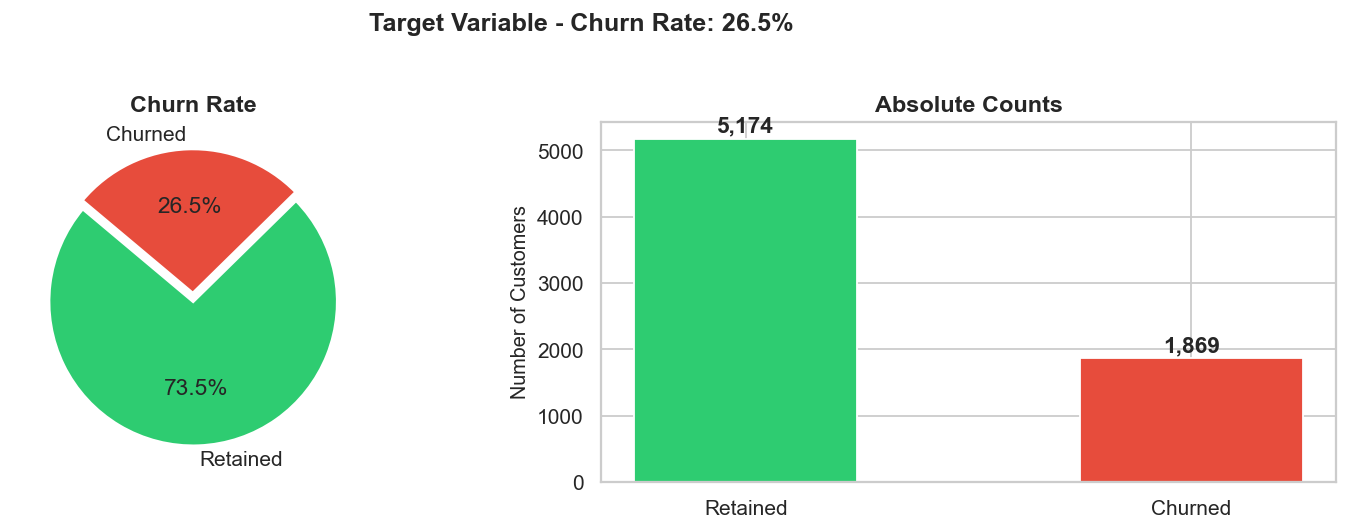

Class imbalance ratio: 1 : 2.77


In [ ]:
# 3.1 Target distribution
churn_counts = df['Churn'].value_counts()
churn_rate   = (df['Churn'] == 'Yes').mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(
    churn_counts,
    labels=['Retained', 'Churned'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=140,
    explode=(0, 0.06),
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'}
)
axes[0].set_title('Churn Rate', fontweight='bold')

bars = axes[1].bar(['Retained', 'Churned'], churn_counts,
                    color=['#2ecc71', '#e74c3c'], width=0.5, edgecolor='white')
for b in bars:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 40,
                 f'{int(b.get_height()):,}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Absolute Counts', fontweight='bold')
axes[1].set_ylabel('Number of Customers')

plt.suptitle(f'Target Variable - Churn Rate: {churn_rate:.1f}%', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_01_target_dist.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Class imbalance ratio: 1 : {churn_counts[0]/churn_counts[1]:.2f}')

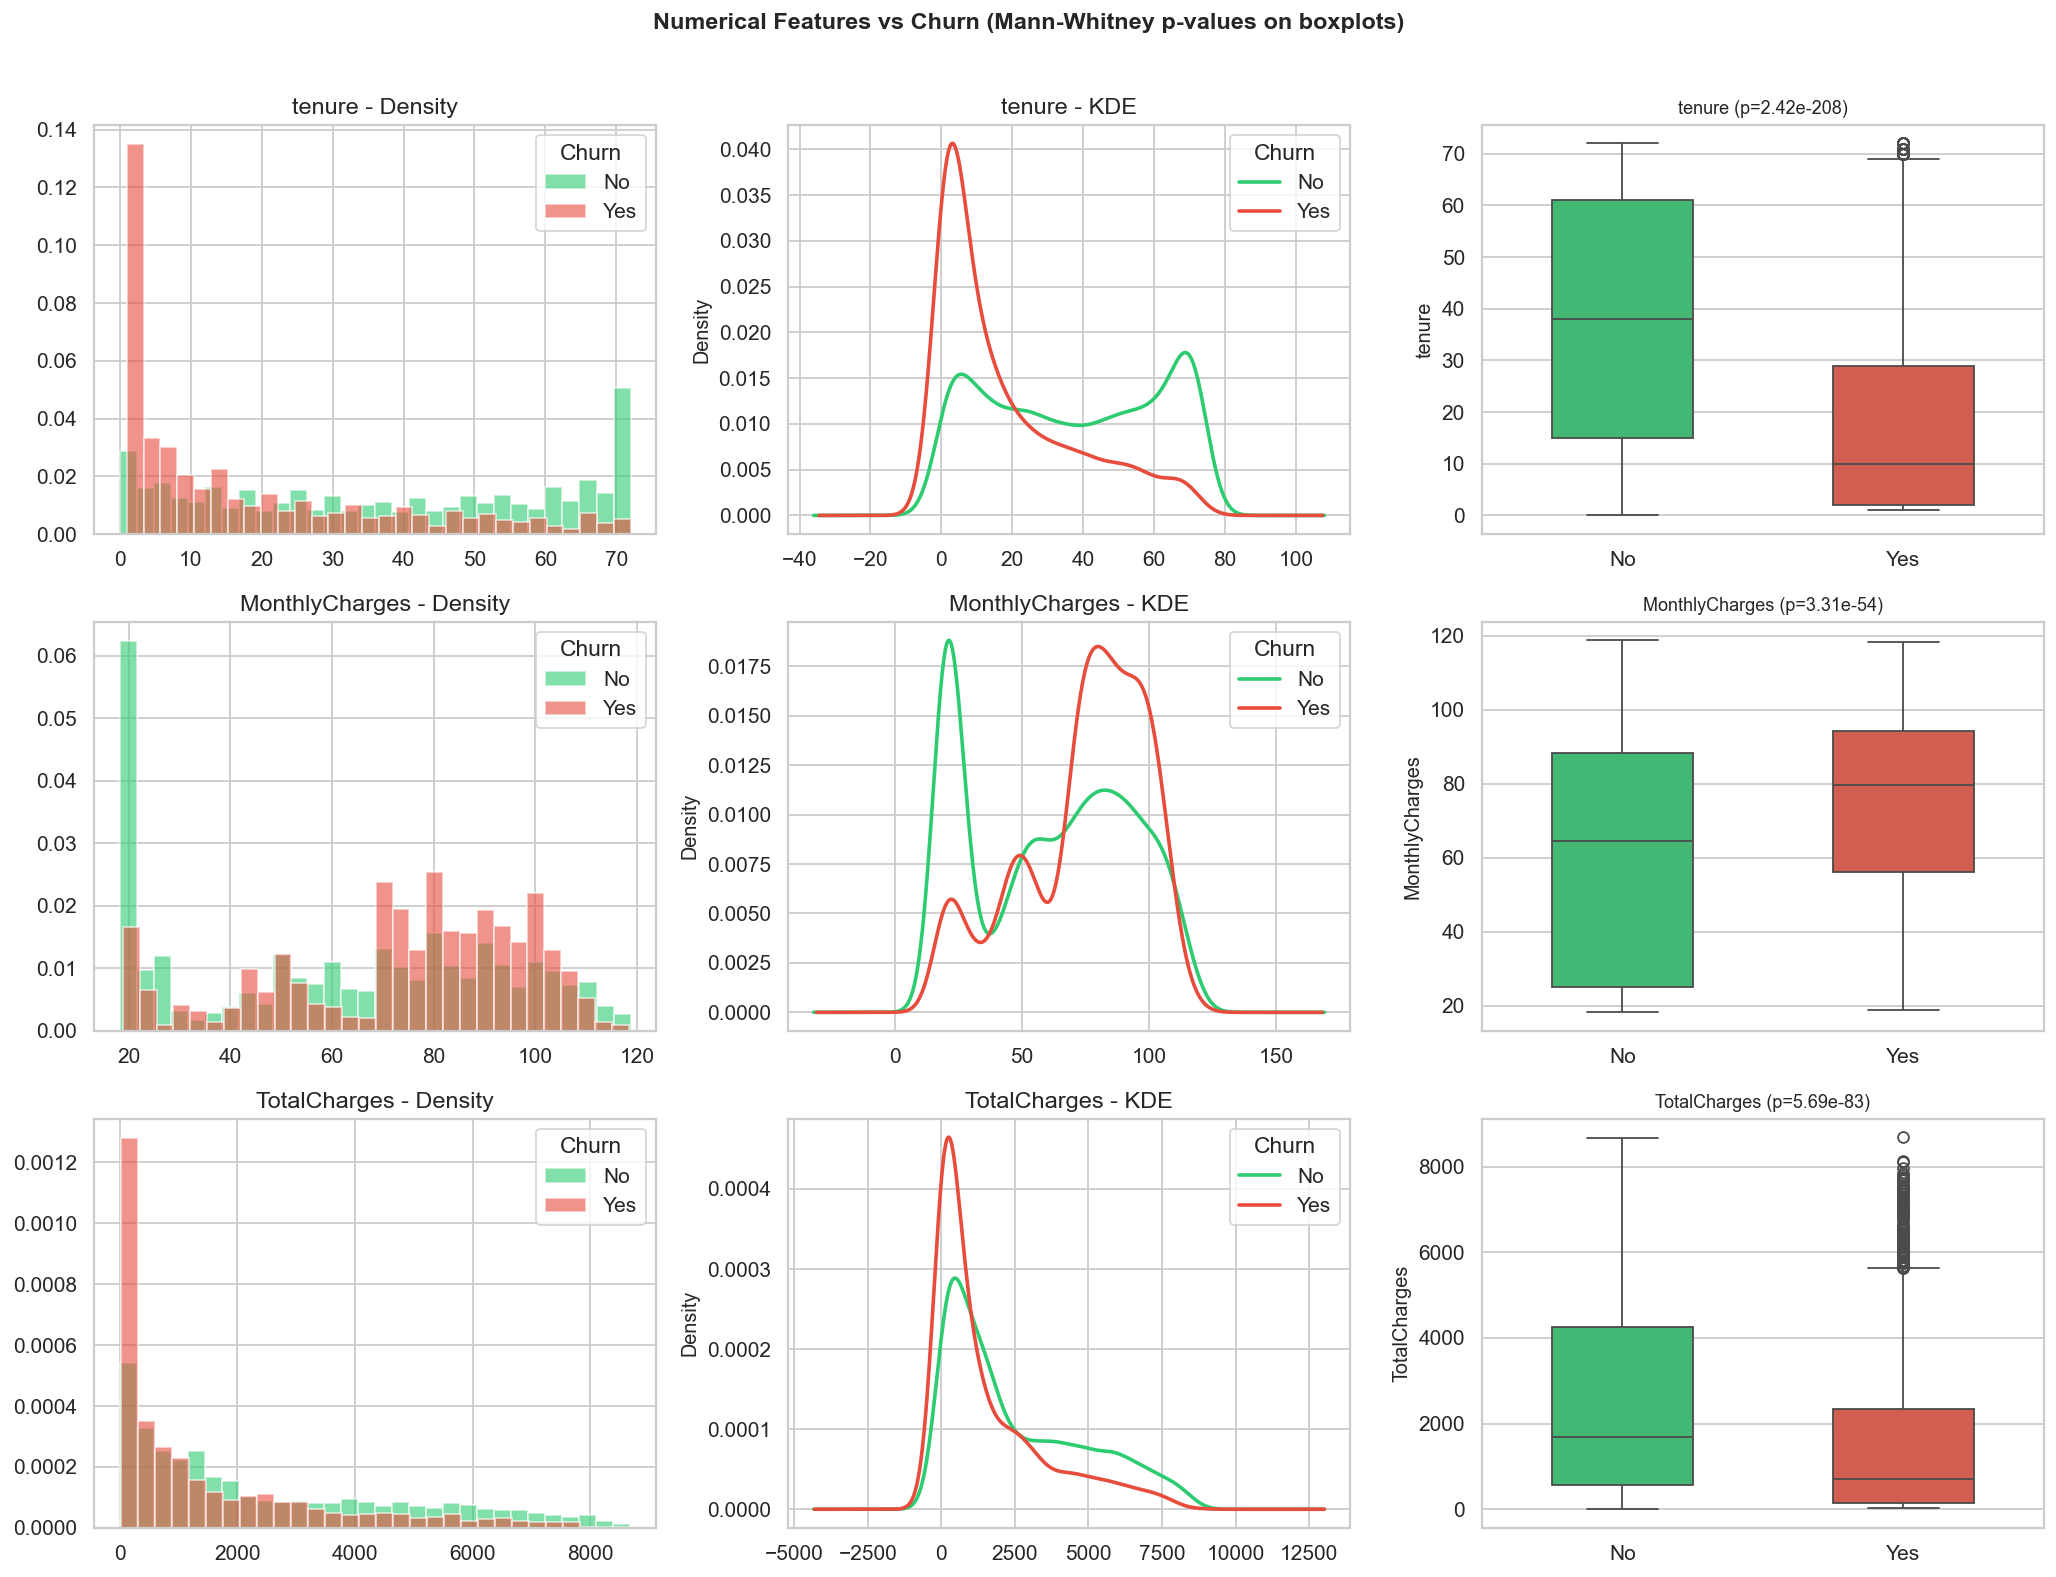

In [ ]:
# 3.2 Numerical distributions by churn
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
palette = {'Yes': '#e74c3c', 'No': '#2ecc71'}

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for i, feat in enumerate(num_features):
    # Histogram
    for label, grp in df.groupby('Churn'):
        axes[i][0].hist(grp[feat], bins=30, alpha=0.6, label=label,
                        color=palette[label], density=True)
    axes[i][0].set_title(f'{feat} - Density')
    axes[i][0].legend(title='Churn')

    # KDE
    for label, grp in df.groupby('Churn'):
        grp[feat].plot.kde(ax=axes[i][1], label=label, color=palette[label], lw=2)
    axes[i][1].set_title(f'{feat} - KDE')
    axes[i][1].legend(title='Churn')

    # Boxplot
    sns.boxplot(data=df, x='Churn', y=feat, palette=palette,
                order=['No','Yes'], ax=axes[i][2], width=0.5)
    axes[i][2].set_title(f'{feat} - Boxplot')

    # Mann-Whitney U-test
    g0 = df.loc[df['Churn']=='No',  feat]
    g1 = df.loc[df['Churn']=='Yes', feat]
    stat, pval = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    for ax in axes[i]:
        ax.set_xlabel('')
    axes[i][2].set_title(f'{feat} (p={pval:.2e})', fontsize=10)

plt.suptitle('Numerical Features vs Churn (Mann-Whitney p-values on boxplots)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_02_num_eda.png', bbox_inches='tight', dpi=150)
plt.show()

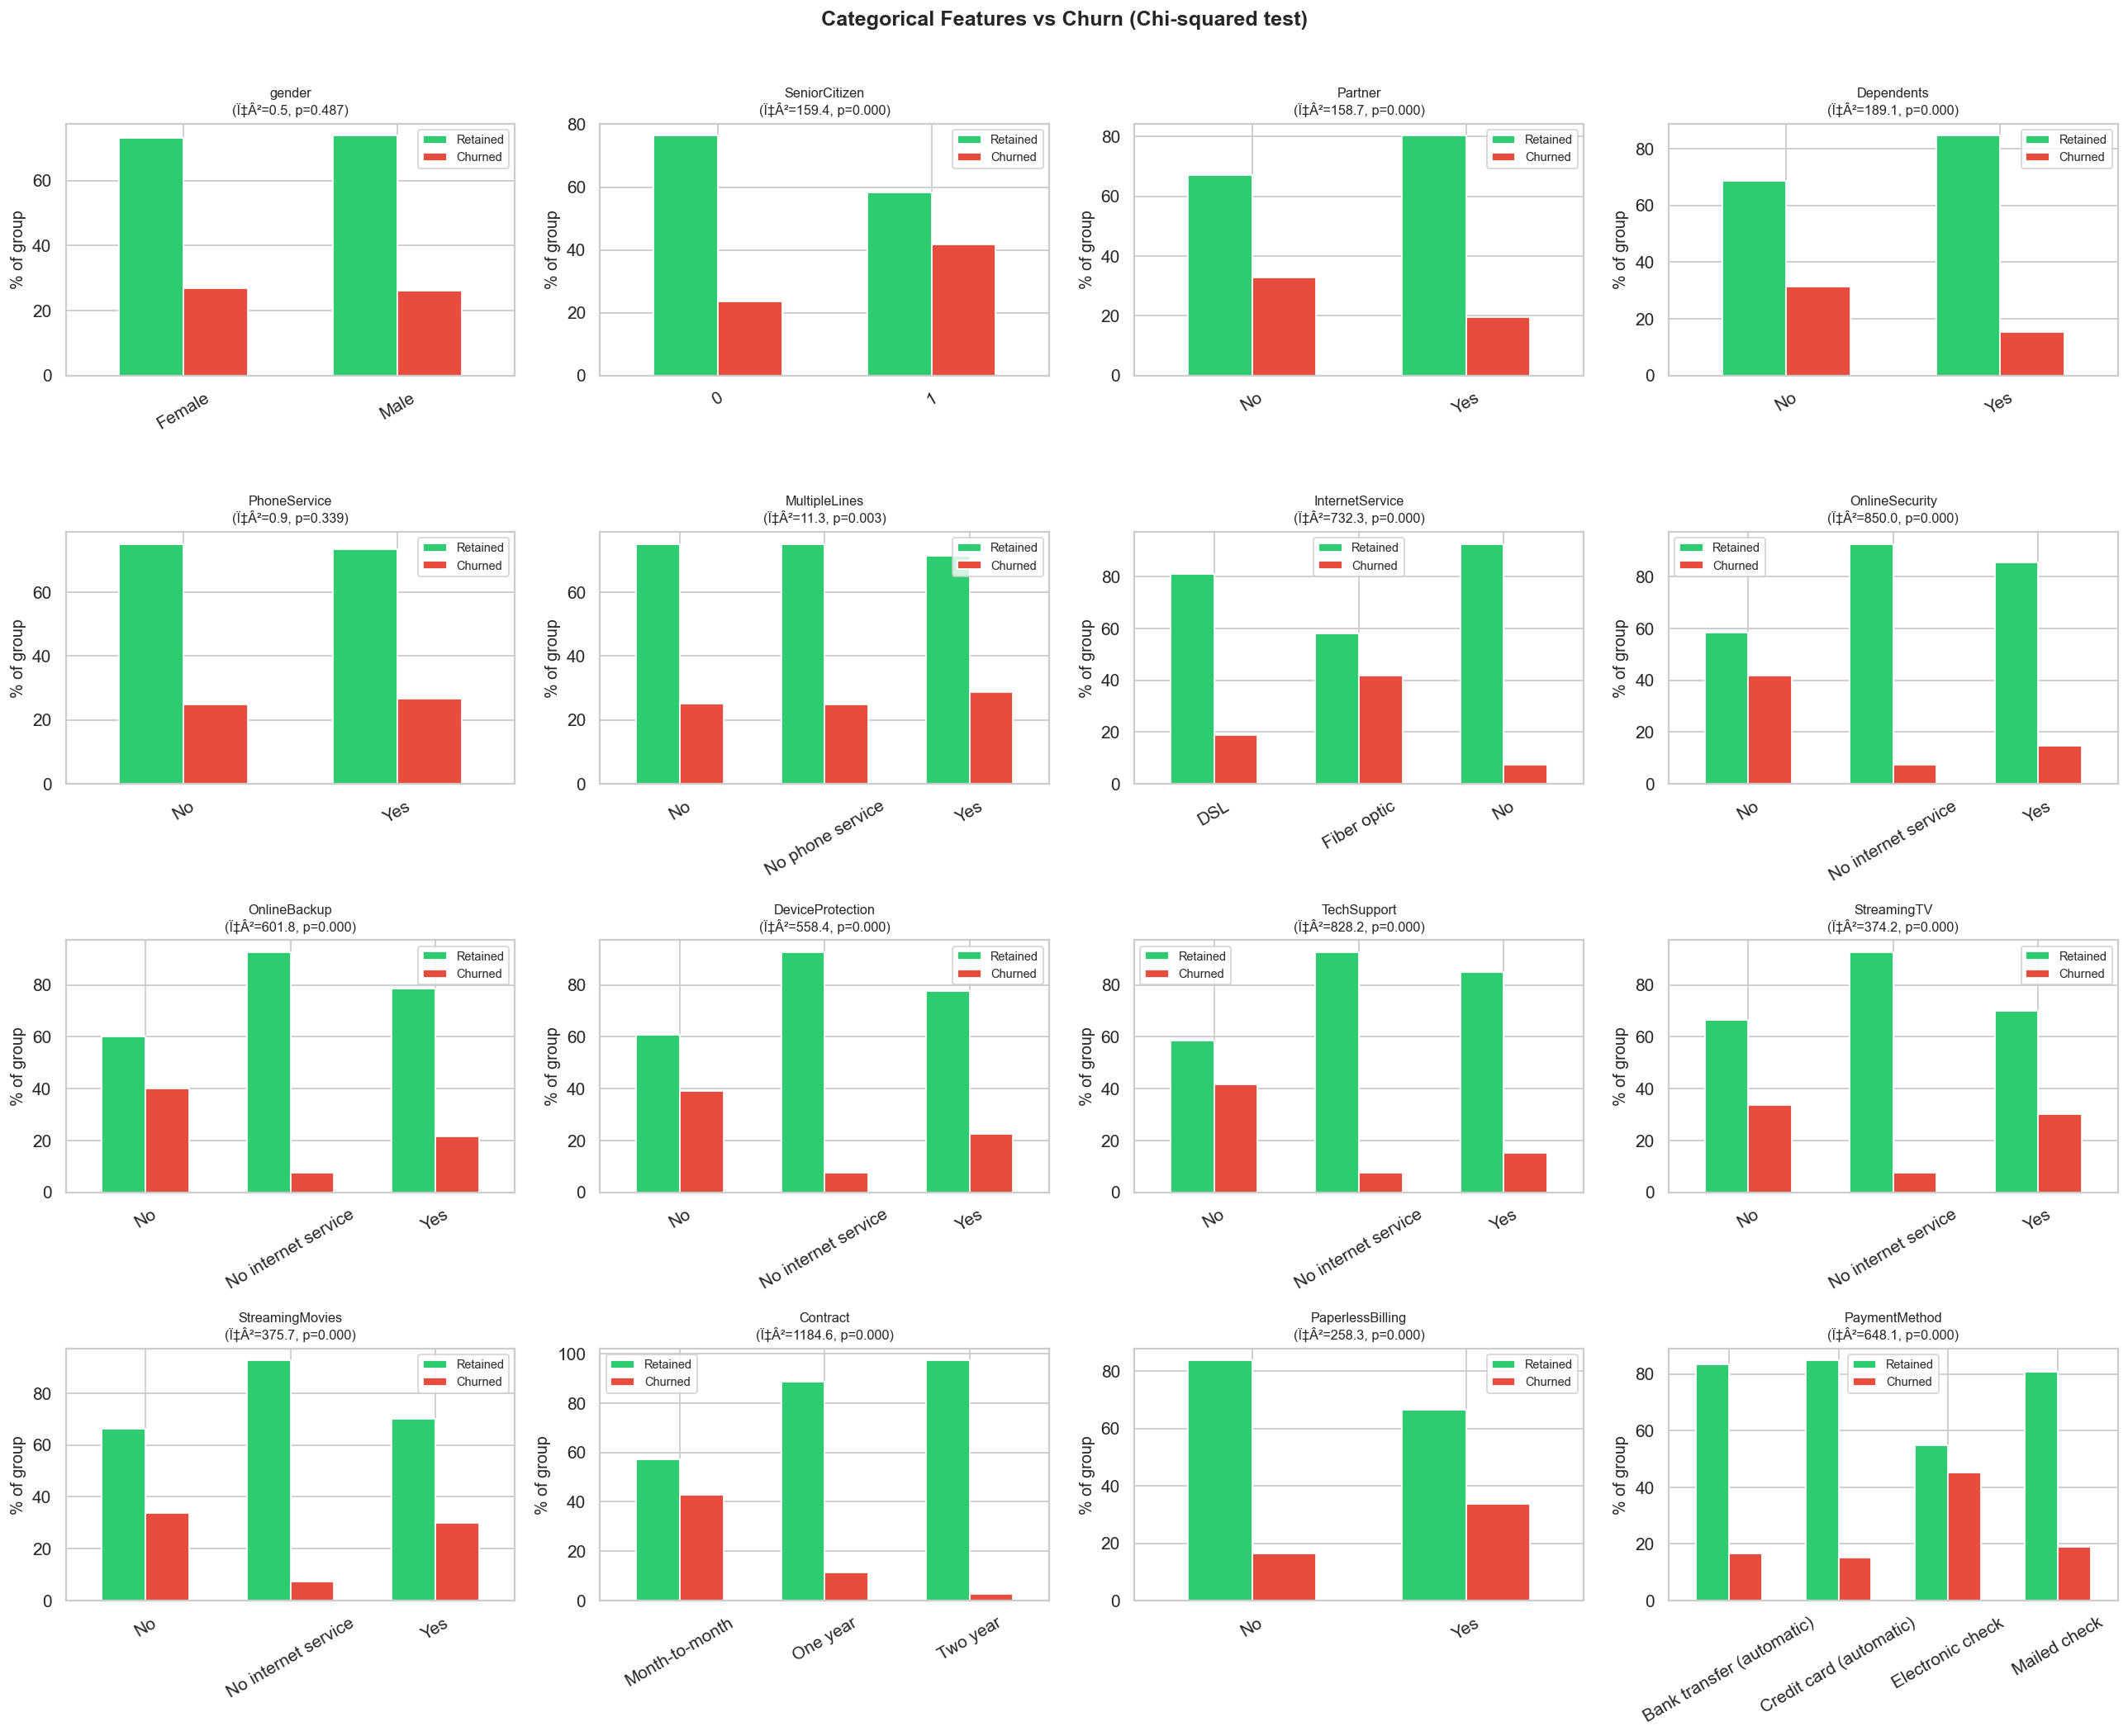

In [ ]:
# 3.3 Categorical churn rates
cat_features = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    ct = pd.crosstab(df[feat], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71','#e74c3c'],
            edgecolor='white', width=0.6)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('% of group')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(['Retained','Churned'], fontsize=8)

    # Chi-squared test
    contingency = pd.crosstab(df[feat], df['Churn'])
    chi2, pval, _, _ = stats.chi2_contingency(contingency)
    axes[i].set_title(f'{feat}\n(Ï‡Â²={chi2:.1f}, p={pval:.3f})', fontsize=9)

# hide unused
for j in range(len(cat_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features vs Churn (Chi-squared test)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_03_cat_eda.png', bbox_inches='tight', dpi=150)
plt.show()

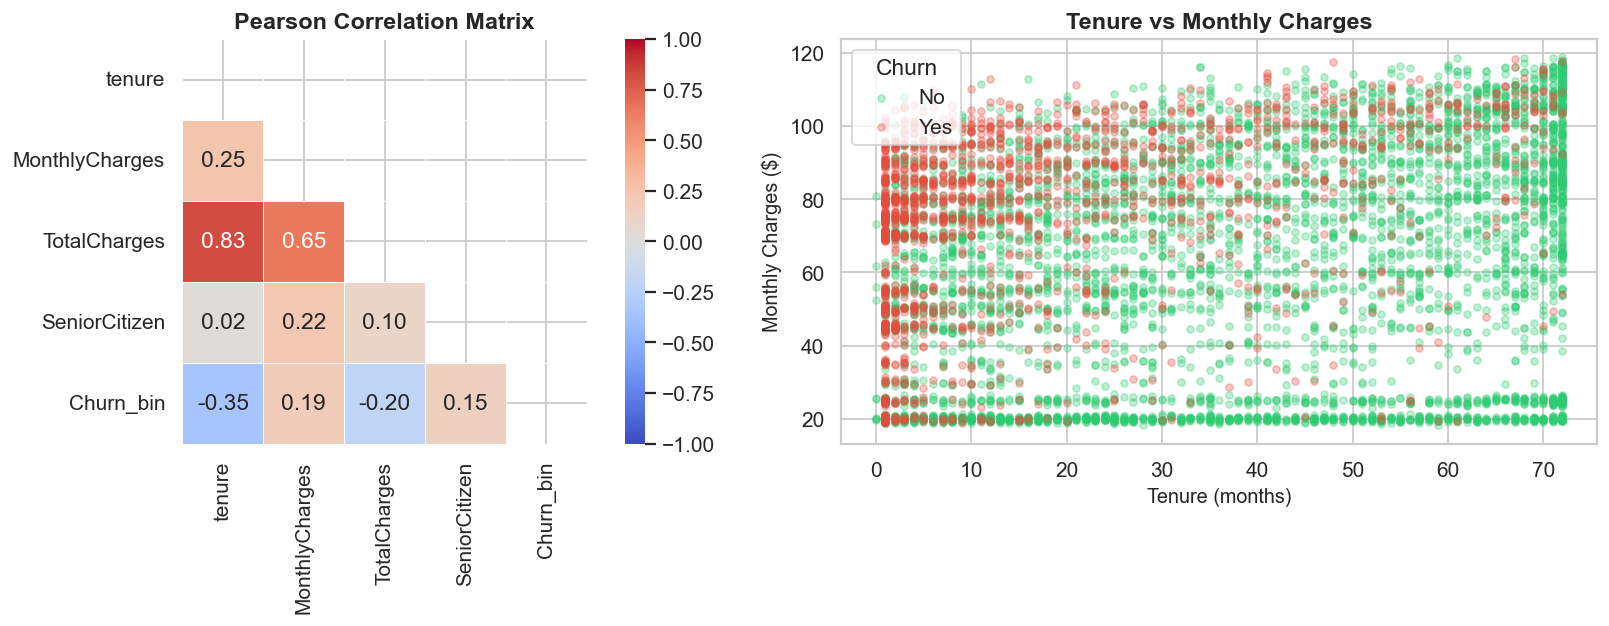

In [ ]:
# 3.4 Correlation & pairplot of numerics
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pearson correlations
corr = df[['tenure','MonthlyCharges','TotalCharges','SeniorCitizen','Churn_bin']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=axes[0], linewidths=0.5, square=True,
            vmin=-1, vmax=1)
axes[0].set_title('Pearson Correlation Matrix', fontweight='bold')

# Tenure vs MonthlyCharges scatter coloured by churn
for label, grp in df.groupby('Churn'):
    axes[1].scatter(grp['tenure'], grp['MonthlyCharges'],
                    alpha=0.3, s=15, c=palette[label], label=label)
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Monthly Charges ($)')
axes[1].set_title('Tenure vs Monthly Charges', fontweight='bold')
axes[1].legend(title='Churn')

plt.tight_layout()
plt.savefig('fig_04_corr.png', bbox_inches='tight', dpi=150)
plt.show()
df.drop('Churn_bin', axis=1, inplace=True)

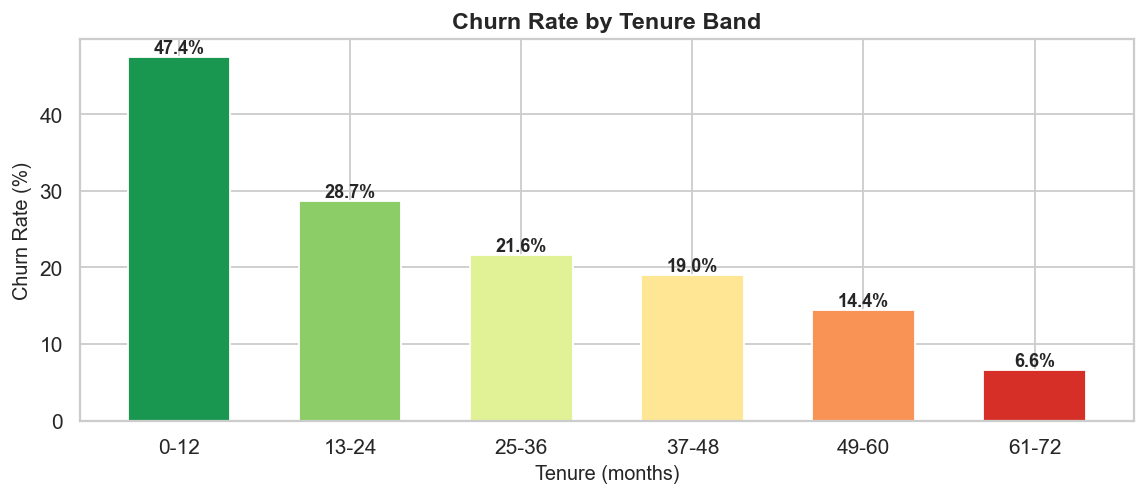

In [ ]:
# 3.5 Tenure segments churn rate
df['tenure_band'] = pd.cut(df['tenure'],
    bins=[0,12,24,36,48,60,72], labels=['0-12','13-24','25-36','37-48','49-60','61-72'],
    include_lowest=True)

seg = df.groupby('tenure_band', observed=True)['Churn'].apply(
    lambda x: (x=='Yes').mean() * 100
).reset_index(name='ChurnRate')

plt.figure(figsize=(9, 4))
bars = plt.bar(seg['tenure_band'].astype(str), seg['ChurnRate'],
               color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(seg))),
               edgecolor='white', width=0.6)
for b, val in zip(bars, seg['ChurnRate']):
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.title('Churn Rate by Tenure Band', fontsize=13, fontweight='bold')
plt.xlabel('Tenure (months)')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('fig_05_tenure_churn.png', bbox_inches='tight', dpi=150)
plt.show()
df.drop('tenure_band', axis=1, inplace=True)

<a id='4'></a>
## 4. Advanced Feature Engineering

In [ ]:
# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Feature engineering constants
# These constants are saved later so the Streamlit app can reproduce the same
# feature engineering without guessing values.
MONTHLY_CHARGE_MEAN = float(df['MonthlyCharges'].mean())
HIGH_CHARGE_THRESHOLD = float(df['MonthlyCharges'].quantile(0.75))
COHORT_MONTHLY_CHARGE_BY_TENURE = (
    df.groupby('tenure')['MonthlyCharges']
      .mean()
      .astype(float)
      .to_dict()
)

# Feature engineering

# 1. Monetary velocity: average monthly spend over tenure.
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

# 2. Spend premium: monthly charge compared with same-tenure customers.
cohort_avg = df['tenure'].map(COHORT_MONTHLY_CHARGE_BY_TENURE)
df['SpendPremium'] = df['MonthlyCharges'] - cohort_avg

# 3. Count of value-added services.
svc_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
df['NumAddOnServices'] = df[svc_cols].apply(
    lambda row: (row == 'Yes').sum(), axis=1
)

# 4. Has phone and internet bundle.
df['HasBundle'] = (
    (df['PhoneService'] == 'Yes') &
    (df['InternetService'].isin(['DSL', 'Fiber optic']))
).astype(int)

# 5. Family presence.
df['HasFamily'] = ((df['Partner'] == 'Yes') | (df['Dependents'] == 'Yes')).astype(int)

# 6. Contract risk score: higher means less risky.
df['ContractRisk'] = df['Contract'].map(
    {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
)

# 7. Auto-payment flag.
df['AutoPay'] = df['PaymentMethod'].str.contains('automatic', case=False).astype(int)

# 8. Interaction: high charges plus low tenure.
df['HighChargesNewCustomer'] = (
    (df['MonthlyCharges'] > HIGH_CHARGE_THRESHOLD) &
    (df['tenure'] < 12)
).astype(int)

# 9. Tenure squared captures non-linear loyalty.
df['Tenure_sq'] = df['tenure'] ** 2

# 10. Log-transform right-skewed charges.
df['LogTotalCharges'] = np.log1p(df['TotalCharges'])
df['LogMonthlyCharges'] = np.log1p(df['MonthlyCharges'])

print('New features added:')
new_feats = [
    'AvgMonthlySpend', 'SpendPremium', 'NumAddOnServices', 'HasBundle',
    'HasFamily', 'ContractRisk', 'AutoPay', 'HighChargesNewCustomer',
    'Tenure_sq', 'LogTotalCharges', 'LogMonthlyCharges'
]
for f in new_feats:
    print(f'  {f}: {df[f].dtype}  |  range [{df[f].min():.2f}, {df[f].max():.2f}]')

print(f'\nTotal features before encoding: {df.shape[1]-1} (+1 target)')

New features added:
  AvgMonthlySpend: float64  |  range [0.00, 118.97]
  SpendPremium: float64  |  range [-61.40, 56.11]
  NumAddOnServices: int64  |  range [0.00, 6.00]
  HasBundle: int32  |  range [0.00, 1.00]
  HasFamily: int32  |  range [0.00, 1.00]
  ContractRisk: int64  |  range [0.00, 2.00]
  AutoPay: int32  |  range [0.00, 1.00]
  HighChargesNewCustomer: int32  |  range [0.00, 1.00]
  Tenure_sq: int64  |  range [0.00, 5184.00]
  LogTotalCharges: float64  |  range [0.00, 9.07]
  LogMonthlyCharges: float64  |  range [2.96, 4.79]

Total features before encoding: 30 (+1 target)


<a id='5'></a>
## 5. Preprocessing Pipeline

In [ ]:
# Encode all categoricals
df_enc = df.copy()

# Gender is not a Yes/No column; encode it separately.
df_enc['gender'] = (
    df_enc['gender'].astype(str).str.strip().str.lower() == 'male'
).astype(int)

# Binary Yes/No columns.
yn_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in yn_cols:
    df_enc[col] = (
        df_enc[col].astype(str).str.strip().str.lower() == 'yes'
    ).astype(int)

# SeniorCitizen is already 0/1 in the raw dataset.
df_enc['SeniorCitizen'] = df_enc['SeniorCitizen'].astype(int)

# Ordinal multi-level categoricals. Note: some variables are nominal in reality.
# For a production model, prefer OneHotEncoder or a categorical-native model.
ordinal_map = {
    'MultipleLines':    {'No phone service': 0, 'No': 1, 'Yes': 2},
    'InternetService':  {'No': 0, 'DSL': 1, 'Fiber optic': 2},
    'OnlineSecurity':   {'No internet service': 0, 'No': 1, 'Yes': 2},
    'OnlineBackup':     {'No internet service': 0, 'No': 1, 'Yes': 2},
    'DeviceProtection': {'No internet service': 0, 'No': 1, 'Yes': 2},
    'TechSupport':      {'No internet service': 0, 'No': 1, 'Yes': 2},
    'StreamingTV':      {'No internet service': 0, 'No': 1, 'Yes': 2},
    'StreamingMovies':  {'No internet service': 0, 'No': 1, 'Yes': 2},
    'Contract':         {'Month-to-month': 0, 'One year': 1, 'Two year': 2},
    'PaymentMethod':    {'Electronic check': 0, 'Mailed check': 1,
                         'Bank transfer (automatic)': 2, 'Credit card (automatic)': 3},
}
for col, mapping in ordinal_map.items():
    df_enc[col] = df_enc[col].map(mapping)

obj_left = df_enc.select_dtypes('object').columns.tolist()
print('Object columns remaining:', obj_left or 'None')
print('Nulls after encoding:', df_enc.isnull().sum().sum())
print('Gender distribution after encoding:', df_enc['gender'].value_counts().to_dict())
print(f'Final feature matrix: {df_enc.shape}')

Object columns remaining: None
Nulls after encoding: 0
Gender distribution after encoding: {1: 3555, 0: 3488}
Final feature matrix: (7043, 31)


In [ ]:
# Train / Test split & SMOTE
X = df_enc.drop('Churn', axis=1)
y = df_enc['Churn']
FEATURE_NAMES = X.columns.tolist()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Scale (RobustScaler - handles outliers in TotalCharges better)
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train_raw)
X_test_sc  = scaler.transform(X_test_raw)

# SMOTE on training set only (never on test!)
sm = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train_sc, y_train)

print('Before SMOTE:', dict(y_train.value_counts()))
print('After  SMOTE:', dict(pd.Series(y_train_sm).value_counts()))
print(f'\nTrain size (balanced): {X_train_sm.shape}')
print(f'Test  size (original): {X_test_sc.shape}')

Before SMOTE: {0: 4139, 1: 1495}
After  SMOTE: {0: 4139, 1: 4139}

Train size (balanced): (8278, 30)
Test  size (original): (1409, 30)


In [ ]:
# Cross-validation strategy
CV = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

def honest_cv_auc(model):
    """Cross-validate preprocessing + SMOTE inside each fold to avoid leakage."""
    cv_pipeline = ImbPipeline(steps=[
        ('scaler', RobustScaler()),
        ('smote', SMOTE(random_state=SEED, k_neighbors=5)),
        ('model', clone(model)),
    ])
    return cross_val_score(
        cv_pipeline, X_train_raw, y_train,
        cv=CV, scoring='roc_auc', n_jobs=-1
    )

def evaluate(name, model, X_tr, y_tr, X_te, y_te, threshold=0.5):
    """Fit on the prepared train matrix, evaluate on untouched test data."""
    model.fit(X_tr, y_tr)
    prob = model.predict_proba(X_te)[:, 1]
    pred = (prob >= threshold).astype(int)

    cv_aucs = honest_cv_auc(model)

    result = {
        'model':    model,
        'name':     name,
        'accuracy': accuracy_score(y_te, pred),
        'recall':   recall_score(y_te, pred),
        'precision':precision_score(y_te, pred),
        'f1':       f1_score(y_te, pred),
        'auc':      roc_auc_score(y_te, prob),
        'ap':       average_precision_score(y_te, prob),
        'brier':    brier_score_loss(y_te, prob),
        'cv_auc_mean': cv_aucs.mean(),
        'cv_auc_std':  cv_aucs.std(),
        'prob':     prob,
        'pred':     pred,
    }
    print(f'{name:30s} | AUC={result["auc"]:.4f}  F1={result["f1"]:.4f}  '
          f'Recall={result["recall"]:.4f}  Honest CV-AUC={result["cv_auc_mean"]:.4f}+/-{result["cv_auc_std"]:.4f}')
    return result

RESULTS = {}

<a id='6'></a>
## 6. Classical ML Models + Hyperparameter Tuning

In [ ]:
# 6.1 Baseline models
print('BASELINE MODELS')
print('-'*90)

baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, C=1.0,
                                               class_weight='balanced', random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=300, max_depth=12,
                                                   class_weight='balanced', random_state=SEED),
    'XGBoost':             XGBClassifier(n_estimators=300, learning_rate=0.05,
                                          max_depth=6, subsample=0.8,
                                          use_label_encoder=False, eval_metric='logloss',
                                          random_state=SEED),
    'LightGBM':            LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                           max_depth=6, class_weight='balanced',
                                           random_state=SEED, verbose=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                        max_depth=5, random_state=SEED),
}

for name, model in baseline_models.items():
    RESULTS[name] = evaluate(name, model, X_train_sm, y_train_sm, X_test_sc, y_test)

BASELINE MODELS
------------------------------------------------------------------------------------------
Logistic Regression            | AUC=0.8452  F1=0.6143  Recall=0.7941  Honest CV-AUC=0.8491+/-0.0154
Random Forest                  | AUC=0.8352  F1=0.6174  Recall=0.6925  Honest CV-AUC=0.8399+/-0.0133
XGBoost                        | AUC=0.8323  F1=0.5778  Recall=0.5856  Honest CV-AUC=0.8355+/-0.0124
LightGBM                       | AUC=0.8313  F1=0.5865  Recall=0.5936  Honest CV-AUC=0.8329+/-0.0115
Gradient Boosting              | AUC=0.8388  F1=0.5840  Recall=0.6043  Honest CV-AUC=0.8411+/-0.0132


In [ ]:
# 6.2 Optuna hyperparameter tuning: XGBoost
print('Tuning XGBoost with Optuna (50 trials, leakage-safe CV pipeline)...')

def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 9),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'use_label_encoder': False,
        'eval_metric': 'logloss',
        'random_state': SEED,
    }
    model = XGBClassifier(**params)
    pipe = ImbPipeline(steps=[
        ('scaler', RobustScaler()),
        ('smote', SMOTE(random_state=SEED, k_neighbors=5)),
        ('model', model),
    ])
    aucs = cross_val_score(
        pipe, X_train_raw, y_train,
        cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
        scoring='roc_auc', n_jobs=-1
    )
    return aucs.mean()

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=False)

best_xgb_params = study_xgb.best_params | {
    'use_label_encoder': False,
    'eval_metric': 'logloss',
    'random_state': SEED,
}
xgb_tuned = XGBClassifier(**best_xgb_params)
RESULTS['XGBoost (Tuned)'] = evaluate(
    'XGBoost (Tuned)', xgb_tuned, X_train_sm, y_train_sm, X_test_sc, y_test
)
print(f'Best XGBoost params: {study_xgb.best_params}')
print(f'Best leakage-safe CV AUC: {study_xgb.best_value:.4f}')

Tuning XGBoost with Optuna (50 trials, leakage-safe CV pipeline)...
XGBoost (Tuned)                | AUC=0.8453  F1=0.6336  Recall=0.7353  Honest CV-AUC=0.8479+/-0.0144
Best XGBoost params: {'n_estimators': 431, 'learning_rate': 0.01414475871474663, 'max_depth': 4, 'subsample': 0.7669585300892232, 'colsample_bytree': 0.5056894766169016, 'min_child_weight': 4, 'reg_alpha': 2.644684158812211, 'reg_lambda': 9.204110244867154}
Best leakage-safe CV AUC: 0.8482


In [ ]:
# 6.3 Optuna: LightGBM
print('Tuning LightGBM with Optuna (50 trials, leakage-safe CV pipeline)...')

def lgbm_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 200),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'class_weight': 'balanced',
        'random_state': SEED,
        'verbose': -1,
    }
    model = LGBMClassifier(**params)
    pipe = ImbPipeline(steps=[
        ('scaler', RobustScaler()),
        ('smote', SMOTE(random_state=SEED, k_neighbors=5)),
        ('model', model),
    ])
    aucs = cross_val_score(
        pipe, X_train_raw, y_train,
        cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
        scoring='roc_auc', n_jobs=-1
    )
    return aucs.mean()

study_lgbm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgbm.optimize(lgbm_objective, n_trials=50, show_progress_bar=False)

lgbm_tuned = LGBMClassifier(**(study_lgbm.best_params | {
    'class_weight': 'balanced',
    'random_state': SEED,
    'verbose': -1,
}))
RESULTS['LightGBM (Tuned)'] = evaluate(
    'LightGBM (Tuned)', lgbm_tuned, X_train_sm, y_train_sm, X_test_sc, y_test
)
print(f'Best leakage-safe LGBM CV AUC: {study_lgbm.best_value:.4f}')

Tuning LightGBM with Optuna (50 trials, leakage-safe CV pipeline)...
LightGBM (Tuned)               | AUC=0.8422  F1=0.6288  Recall=0.7246  Honest CV-AUC=0.8475+/-0.0143
Best leakage-safe LGBM CV AUC: 0.8473


In [ ]:
# 6.4 Stacking Ensemble
print('Training Stacking Ensemble...')

estimators = [
    ('xgb',  XGBClassifier(**best_xgb_params)),
    ('lgbm', lgbm_tuned),
    ('rf',   RandomForestClassifier(n_estimators=300, max_depth=12,
                                     class_weight='balanced', random_state=SEED)),
]
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, C=1.0),
    cv=5,
    passthrough=False,
    n_jobs=-1,
)
RESULTS['Stacking Ensemble'] = evaluate('Stacking Ensemble', stack,
                                          X_train_sm, y_train_sm, X_test_sc, y_test)

Training Stacking Ensemble...


Stacking Ensemble              | AUC=0.8369  F1=0.6225  Recall=0.6791  Honest CV-AUC=0.8430+/-0.0137


<a id='7'></a>
## 7. Deep Learning - ANN with Keras

In [ ]:
# 7.1 Architecture
INPUT_DIM = X_train_sm.shape[1]

def build_ann(input_dim, units=(256,128,64,32), dropout=(0.4,0.3,0.2,0.1), l2_reg=1e-4, lr=1e-3):
    inp = Input(shape=(input_dim,), name='input')
    x   = inp
    for i, (u, d) in enumerate(zip(units, dropout)):
        x = Dense(u, kernel_regularizer=l2(l2_reg), name=f'dense_{i+1}')(x)
        x = BatchNormalization(name=f'bn_{i+1}')(x)
        x = PReLU(name=f'prelu_{i+1}')(x)       # learnable activation
        x = Dropout(d, name=f'drop_{i+1}')(x)
    out = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='ChurnANN')
    model.compile(
        optimizer=Adam(learning_rate=lr, clipnorm=1.0),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(name='recall'),
            'accuracy'
        ]
    )
    return model

ann = build_ann(INPUT_DIM)
ann.summary()


Model: "ChurnANN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 30)]              0         
                                                                 
 dense_1 (Dense)             (None, 256)               7936      
                                                                 
 bn_1 (BatchNormalization)   (None, 256)               1024      
                                                                 
 prelu_1 (PReLU)             (None, 256)               256       
                                                                 
 drop_1 (Dropout)            (None, 256)               0         
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 bn_2 (BatchNormalization)   (None, 128)               51

In [ ]:
# 7.2 Training
os.makedirs('models', exist_ok=True)

X_ann_train, X_ann_val, y_ann_train, y_ann_val = train_test_split(
    X_train_sm, y_train_sm,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train_sm
)

callbacks = [
    EarlyStopping(
        monitor='val_auc', patience=20,
        restore_best_weights=True, mode='max', verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.4,
        patience=8, min_lr=1e-7, verbose=1
    ),
    ModelCheckpoint(
        'models/ann_best.weights.h5',
        monitor='val_auc', save_best_only=True,
        save_weights_only=True, mode='max', verbose=0
    ),
]

n_neg = (y_ann_train == 0).sum()
n_pos = (y_ann_train == 1).sum()
class_weight = {0: 1.0, 1: n_neg / n_pos}

history = ann.fit(
    X_ann_train, y_ann_train,
    epochs=150,
    batch_size=128,
    validation_data=(X_ann_val, y_ann_val),
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)
print(f'Training stopped at epoch {len(history.history["loss"])}')

Epoch 1/150


55/55 [==============================] - 7s 27ms/step - loss: 0.5870 - auc: 0.7902 - recall: 0.7959 - accuracy: 0.7173 - val_loss: 0.5699 - val_auc: 0.8516 - val_recall: 0.8696 - val_accuracy: 0.7617 - lr: 0.0010
Epoch 2/150
55/55 [==============================] - 1s 10ms/step - loss: 0.5330 - auc: 0.8372 - recall: 0.8169 - accuracy: 0.7609 - val_loss: 0.5570 - val_auc: 0.8595 - val_recall: 0.9340 - val_accuracy: 0.7254 - lr: 0.0010
Epoch 3/150
55/55 [==============================] - 0s 9ms/step - loss: 0.5177 - auc: 0.8482 - recall: 0.8073 - accuracy: 0.7705 - val_loss: 0.5390 - val_auc: 0.8583 - val_recall: 0.9195 - val_accuracy: 0.7432 - lr: 0.0010
Epoch 4/150
55/55 [==============================] - 0s 9ms/step - loss: 0.5173 - auc: 0.8491 - recall: 0.8113 - accuracy: 0.7753 - val_loss: 0.5263 - val_auc: 0.8579 - val_recall: 0.8808 - val_accuracy: 0.7407 - lr: 0.0010
Epoch 5/150
55/55 [==============================] - 1s 11ms/step - loss: 0.5112 - auc: 0.8526 - rec

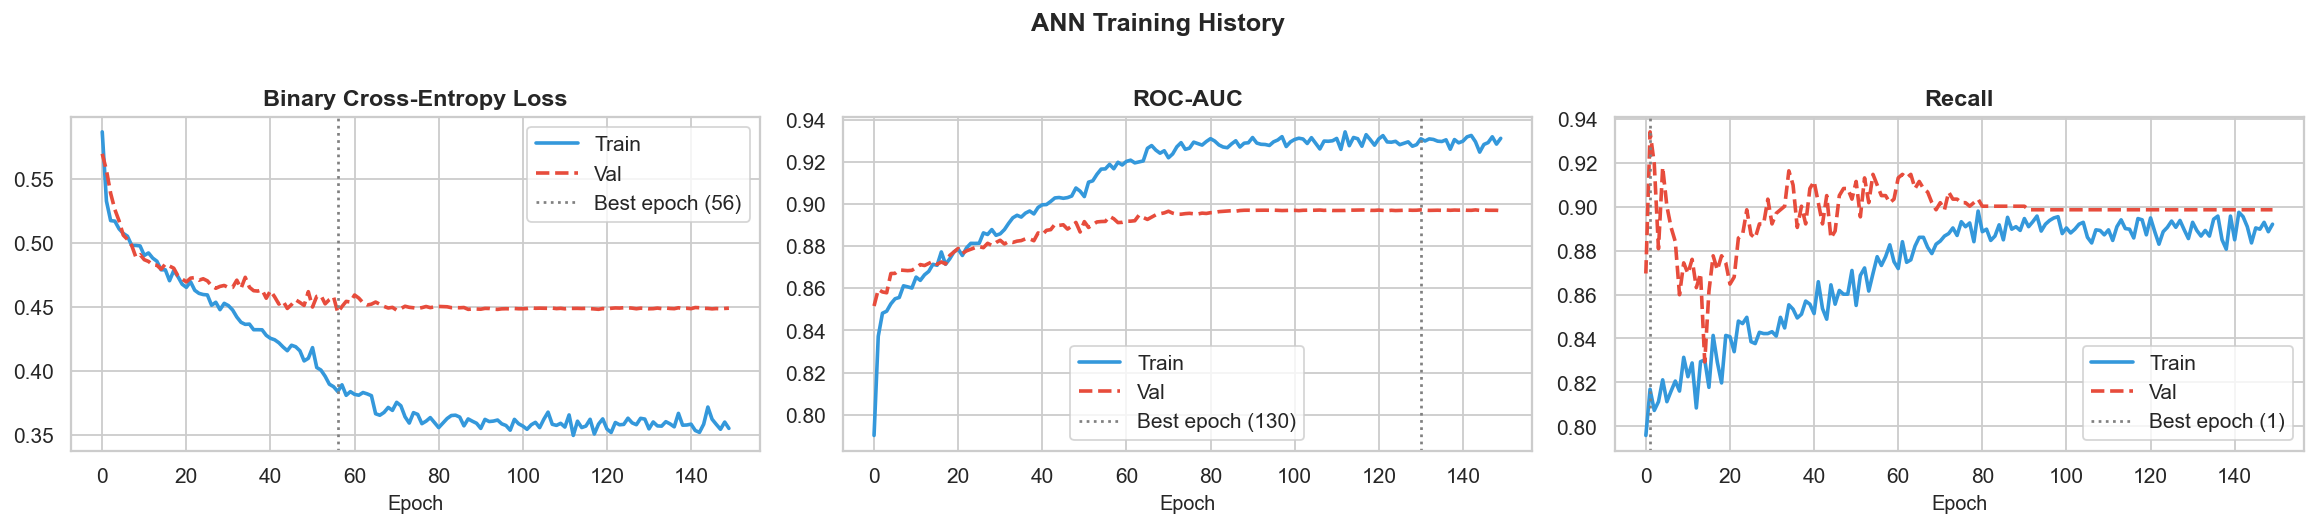

In [ ]:
# 7.3 Training curves
hist_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (tr_key, val_key), title in zip(
    axes,
    [('loss','val_loss'), ('auc','val_auc'), ('recall','val_recall')],
    ['Binary Cross-Entropy Loss', 'ROC-AUC', 'Recall']
):
    ax.plot(hist_df[tr_key],  label='Train', color='#3498db', lw=2)
    ax.plot(hist_df[val_key], label='Val',   color='#e74c3c', lw=2, linestyle='--')
    best_ep = hist_df[val_key].idxmax() if 'loss' not in val_key else hist_df[val_key].idxmin()
    ax.axvline(best_ep, color='gray', linestyle=':', lw=1.5, label=f'Best epoch ({best_ep})')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.set_xlabel('Epoch')

plt.suptitle('ANN Training History', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_06_ann_history.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# 7.4 Threshold tuning on validation data
ann_prob_val = ann.predict(X_ann_val).flatten()
precisions, recalls, thresholds = precision_recall_curve(y_ann_val, ann_prob_val)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)

# precision_recall_curve returns one extra precision/recall point without a
# matching threshold, so threshold selection uses f1s[:-1].
best_idx = int(np.nanargmax(f1s[:-1]))
best_thresh = float(thresholds[best_idx])
print(f'Optimal validation threshold (F1-maximising): {best_thresh:.3f}')

ann_prob_test = ann.predict(X_test_sc).flatten()
ann_pred_tuned = (ann_prob_test >= best_thresh).astype(int)

ann_result = {
    'model':     ann,
    'name':      'ANN (Deep Learning)',
    'accuracy':  accuracy_score(y_test, ann_pred_tuned),
    'recall':    recall_score(y_test, ann_pred_tuned),
    'precision': precision_score(y_test, ann_pred_tuned),
    'f1':        f1_score(y_test, ann_pred_tuned),
    'auc':       roc_auc_score(y_test, ann_prob_test),
    'ap':        average_precision_score(y_test, ann_prob_test),
    'brier':     brier_score_loss(y_test, ann_prob_test),
    'cv_auc_mean': roc_auc_score(y_test, ann_prob_test),
    'cv_auc_std':  0.0,
    'prob':      ann_prob_test,
    'pred':      ann_pred_tuned,
    'threshold': best_thresh,
}
RESULTS['ANN (Deep Learning)'] = ann_result
print(f'ANN - AUC={ann_result["auc"]:.4f}  F1={ann_result["f1"]:.4f}  '
      f'Recall={ann_result["recall"]:.4f}  Precision={ann_result["precision"]:.4f}')

39/39 [==============================] - 0s 2ms/step
Optimal validation threshold (F1-maximising): 0.551
45/45 [==============================] - 0s 2ms/step
ANN - AUC=0.8163  F1=0.6110  Recall=0.7139  Precision=0.5340


<a id='8'></a>
## 8. Model Comparison & Statistical Testing

In [ ]:
# 8.1 Summary table
summary_rows = []
for name, r in RESULTS.items():
    summary_rows.append({
        'Model':       name,
        'Accuracy':    r['accuracy'],
        'Recall':      r['recall'],
        'Precision':   r['precision'],
        'F1-Score':    r['f1'],
        'ROC-AUC':     r['auc'],
        'Avg Prec':    r['ap'],
        'Brier Score': r['brier'],
        'CV-AUC (meanÂ±std)': f"{r['cv_auc_mean']:.4f} Â± {r['cv_auc_std']:.4f}",
    })

summary = pd.DataFrame(summary_rows).set_index('Model').sort_values('ROC-AUC', ascending=False)

# Style for display
styled = summary.style\
    .background_gradient(subset=['ROC-AUC','F1-Score','Recall'], cmap='YlGn')\
    .background_gradient(subset=['Brier Score'], cmap='YlOrRd')\
    .format({'Accuracy':'{:.4f}','Recall':'{:.4f}','Precision':'{:.4f}',
             'F1-Score':'{:.4f}','ROC-AUC':'{:.4f}',
             'Avg Prec':'{:.4f}','Brier Score':'{:.4f}'})

print('MODEL COMPARISON SUMMARY')
display(styled)

MODEL COMPARISON SUMMARY


,Accuracy,Recall,Precision,F1-Score,ROC-AUC,Avg Prec,Brier Score,CV-AUC (meanÂ±std)
Model,,,,,,,,
XGBoost (Tuned),0.7743,0.7353,0.5567,0.6336,0.8453,0.6578,0.1474,0.8479 Â± 0.0144
Logistic Regression,0.7353,0.7941,0.5008,0.6143,0.8452,0.6609,0.1649,0.8491 Â± 0.0154
LightGBM (Tuned),0.7729,0.7246,0.5553,0.6288,0.8422,0.6522,0.1480,0.8475 Â± 0.0143
Gradient Boosting,0.7715,0.6043,0.5650,0.5840,0.8388,0.6372,0.1449,0.8411 Â± 0.0132
Stacking Ensemble,0.7814,0.6791,0.5747,0.6225,0.8369,0.6397,0.1529,0.8430 Â± 0.0137
Random Forest,0.7722,0.6925,0.5570,0.6174,0.8352,0.6358,0.1510,0.8399 Â± 0.0133
XGBoost,0.7729,0.5856,0.5703,0.5778,0.8323,0.6238,0.1474,0.8355 Â± 0.0124
LightGBM,0.7779,0.5936,0.5796,0.5865,0.8313,0.6214,0.1471,0.8329 Â± 0.0115
ANN (Deep Learning),0.7587,0.7139,0.5340,0.6110,0.8163,0.6179,0.1809,0.8163 Â± 0.0000


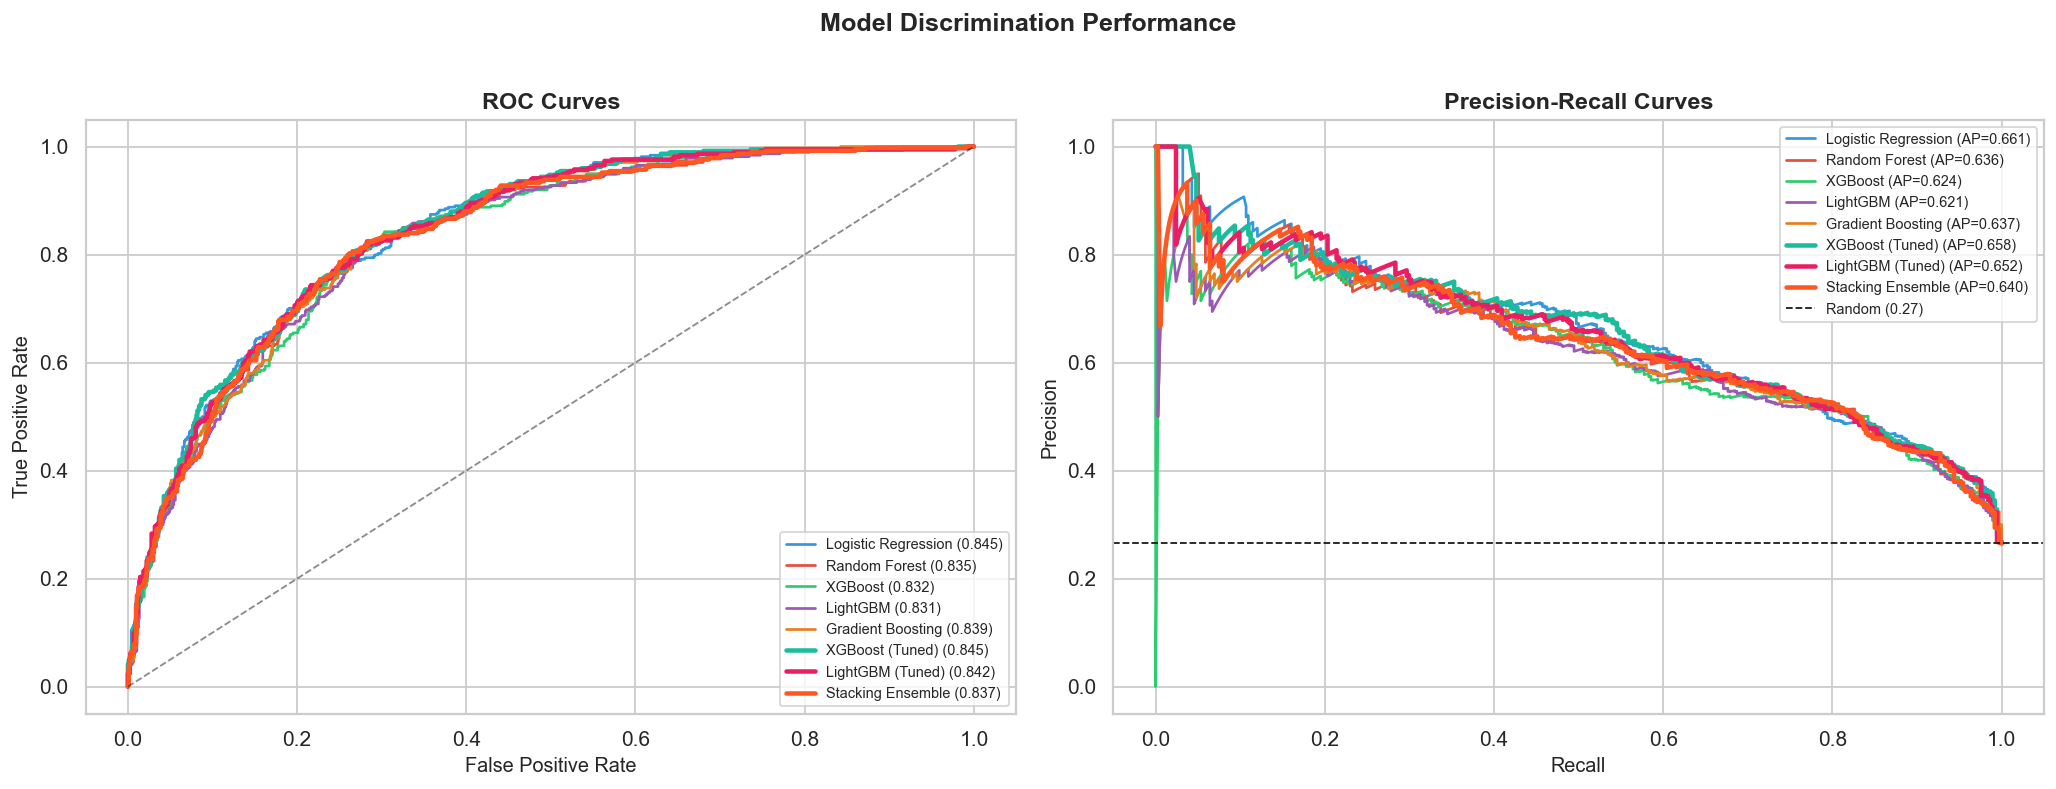

In [ ]:
# 8.2 ROC curves (all models)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#e67e22','#1abc9c','#e91e63','#ff5722']

# ROC
for (name, r), c in zip(RESULTS.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['prob'])
    lw = 2.5 if 'Tuned' in name or 'Ensemble' in name or 'ANN' in name else 1.5
    axes[0].plot(fpr, tpr, label=f"{name} ({r['auc']:.3f})", color=c, lw=lw)

axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
axes[0].fill_between([0,1],[0,1],[0,1], alpha=0.04, color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=8)

# Precision-Recall
for (name, r), c in zip(RESULTS.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, r['prob'])
    lw = 2.5 if 'Tuned' in name or 'Ensemble' in name or 'ANN' in name else 1.5
    axes[1].plot(rec, prec, label=f"{name} (AP={r['ap']:.3f})", color=c, lw=lw)

baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color='k', linestyle='--', lw=1, label=f'Random ({baseline_pr:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend(loc='upper right', fontsize=8)

plt.suptitle('Model Discrimination Performance', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_07_roc_pr.png', bbox_inches='tight', dpi=150)
plt.show()

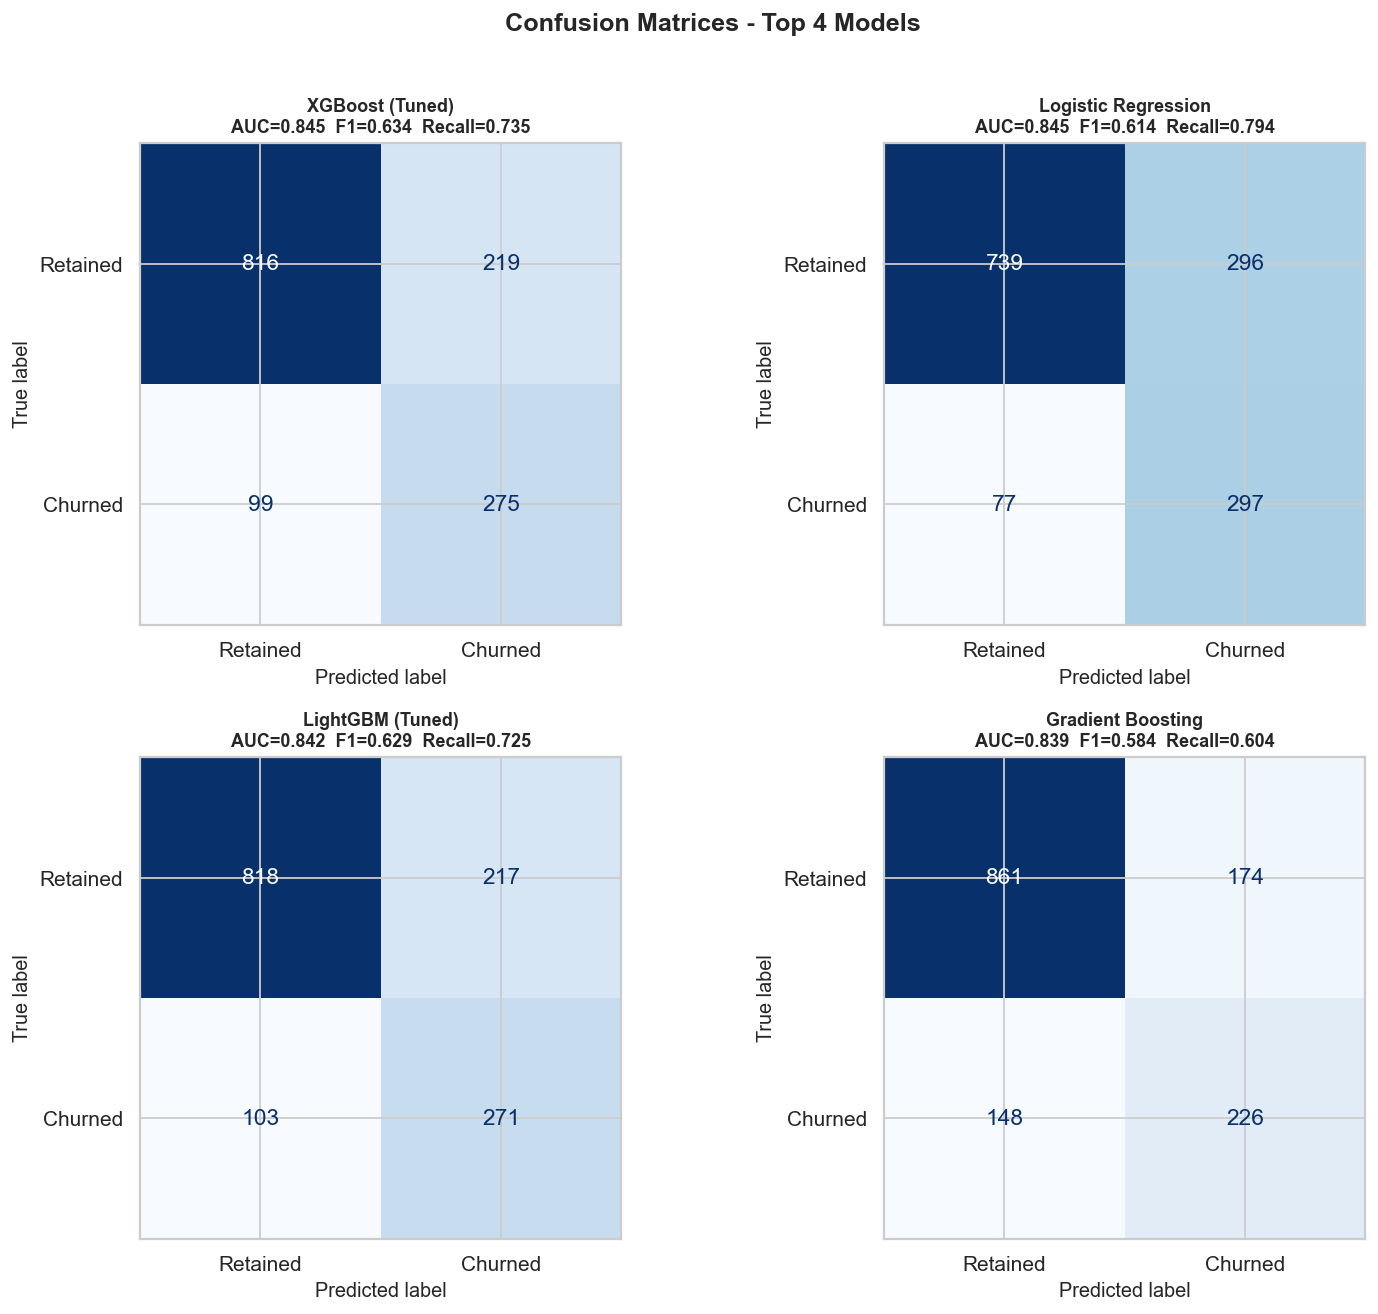

In [ ]:
# 8.3 Confusion matrices (top 4 models)
top4 = list(summary.index[:4])
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, name in enumerate(top4):
    r  = RESULTS[name]
    cm = confusion_matrix(y_test, r['pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Retained','Churned'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(
        f'{name}\nAUC={r["auc"]:.3f}  F1={r["f1"]:.3f}  Recall={r["recall"]:.3f}',
        fontsize=10, fontweight='bold'
    )

plt.suptitle('Confusion Matrices - Top 4 Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_08_cm.png', bbox_inches='tight', dpi=150)
plt.show()

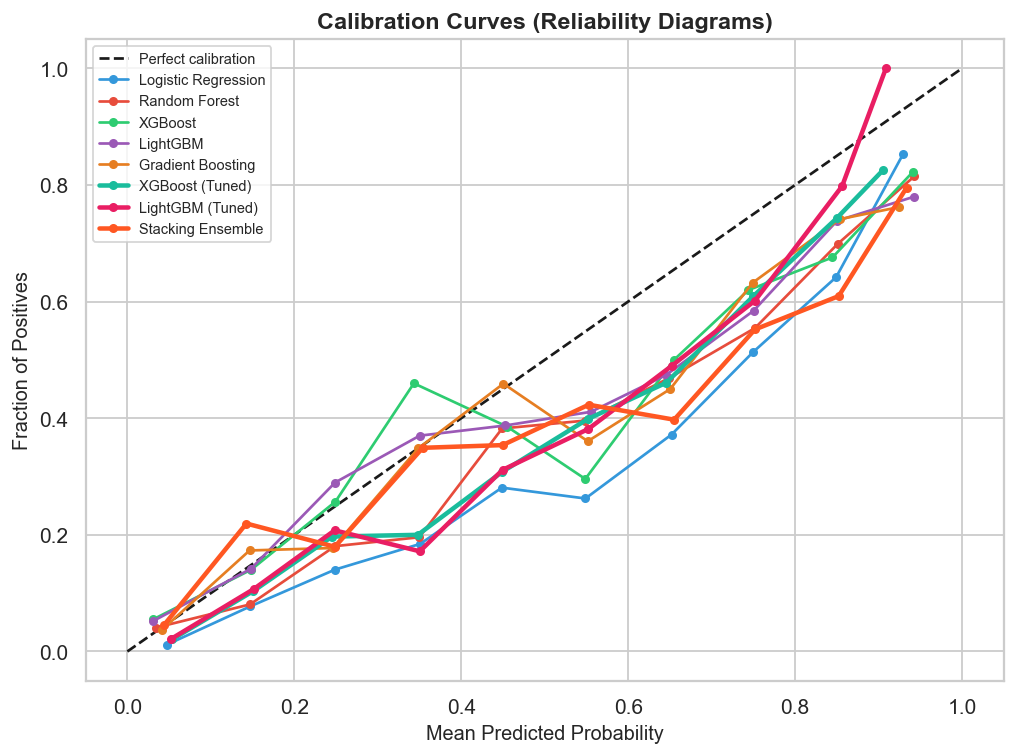

Well-calibrated models stay close to the diagonal.


In [ ]:
# 8.4 Calibration curves
plt.figure(figsize=(8, 6))
plt.plot([0,1],[0,1], 'k--', lw=1.5, label='Perfect calibration')

for (name, r), c in zip(RESULTS.items(), colors):
    fraction_pos, mean_pred = calibration_curve(y_test, r['prob'], n_bins=10)
    lw = 2.5 if 'Tuned' in name or 'Ensemble' in name else 1.5
    plt.plot(mean_pred, fraction_pos, marker='o', label=name, color=c, lw=lw, markersize=4)

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curves (Reliability Diagrams)', fontweight='bold')
plt.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('fig_09_calibration.png', bbox_inches='tight', dpi=150)
plt.show()
print('Well-calibrated models stay close to the diagonal.')

In [ ]:
# 8.5 Paired bootstrap AUC comparison
best_name = summary.index[0]
best_prob = RESULTS[best_name]['prob']

print(f'Paired bootstrap AUC comparison vs best model ({best_name})')
print('-' * 70)

rng = np.random.default_rng(SEED)
n_boot = 1000
y_test_array = np.asarray(y_test)

for name, r in RESULTS.items():
    if name == best_name:
        continue

    other_prob = np.asarray(r['prob'])
    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_test_array), len(y_test_array))
        if len(np.unique(y_test_array[idx])) < 2:
            continue
        best_auc = roc_auc_score(y_test_array[idx], best_prob[idx])
        other_auc = roc_auc_score(y_test_array[idx], other_prob[idx])
        diffs.append(best_auc - other_auc)

    diffs = np.asarray(diffs)
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    p_value = 2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0))
    print(f'  {name:30s} | AUC diff={diffs.mean():+.4f}  '
          f'95% CI [{ci_low:+.4f}, {ci_high:+.4f}]  p~{p_value:.4f}')

print('\nPositive AUC diff means the best model has higher bootstrapped AUC.')

Paired bootstrap AUC comparison vs best model (XGBoost (Tuned))
----------------------------------------------------------------------
  Logistic Regression            | AUC diff=+0.0002  95% CI [-0.0060, +0.0061]  p~0.9420
  Random Forest                  | AUC diff=+0.0103  95% CI [+0.0028, +0.0175]  p~0.0040
  XGBoost                        | AUC diff=+0.0131  95% CI [+0.0059, +0.0213]  p~0.0020
  LightGBM                       | AUC diff=+0.0142  95% CI [+0.0058, +0.0220]  p~0.0020
  Gradient Boosting              | AUC diff=+0.0065  95% CI [+0.0006, +0.0128]  p~0.0260
  LightGBM (Tuned)               | AUC diff=+0.0031  95% CI [+0.0005, +0.0059]  p~0.0200
  Stacking Ensemble              | AUC diff=+0.0083  95% CI [+0.0023, +0.0150]  p~0.0100
  ANN (Deep Learning)            | AUC diff=+0.0291  95% CI [+0.0166, +0.0426]  p~0.0000

Positive AUC diff means the best model has higher bootstrapped AUC.


<a id='9'></a>
## 9. Explainability - SHAP & Permutation Importance

In [ ]:
# 9.1 SHAP - XGBoost Tuned
xgb_best = RESULTS['XGBoost (Tuned)']['model']
explainer = shap.Explainer(xgb_best, feature_names=FEATURE_NAMES)
shap_vals = explainer(X_test_sc)

print(f'SHAP values shape: {shap_vals.values.shape}')
print('Computing global importance...')

SHAP values shape: (1409, 30)
Computing global importance...


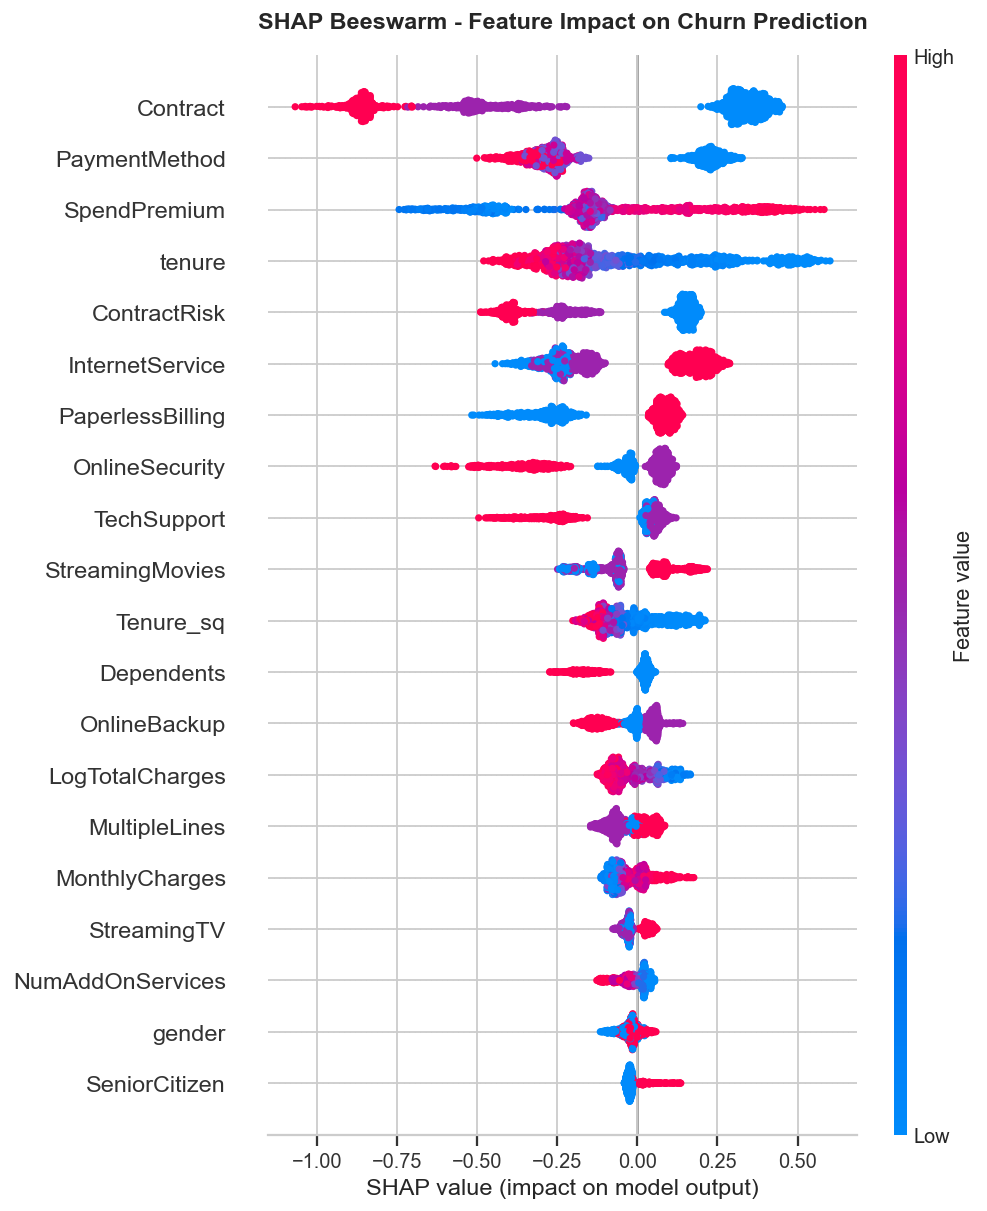

In [ ]:
# Beeswarm - global feature importance + directionality
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_test_sc, feature_names=FEATURE_NAMES,
                  max_display=20, show=False)
plt.title('SHAP Beeswarm - Feature Impact on Churn Prediction', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_10_shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()

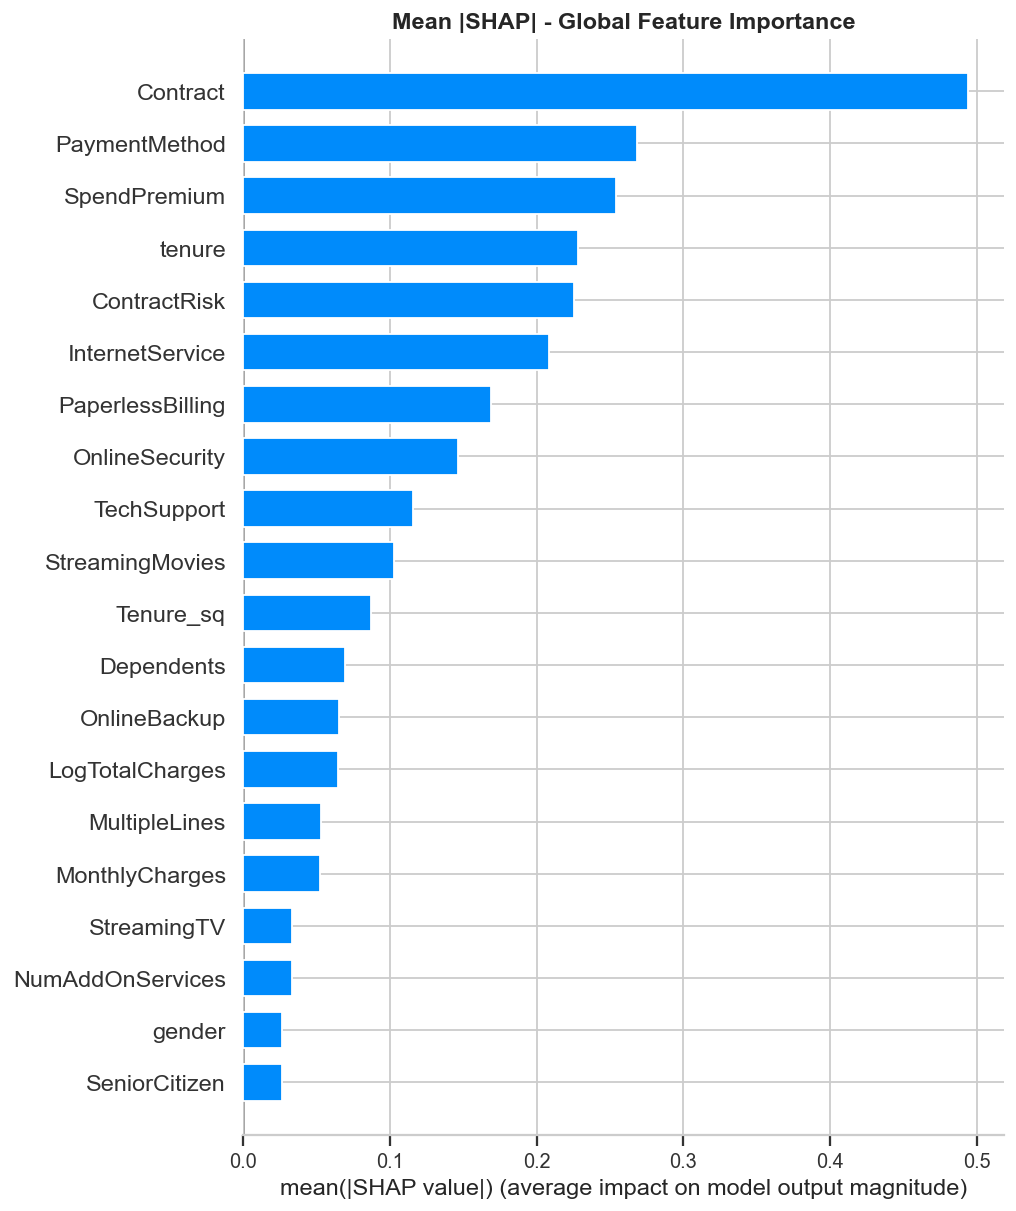

In [ ]:
# Bar - mean |SHAP|
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_vals, X_test_sc, feature_names=FEATURE_NAMES,
                  plot_type='bar', max_display=20, show=False)
plt.title('Mean |SHAP| - Global Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_11_shap_bar.png', bbox_inches='tight', dpi=150)
plt.show()

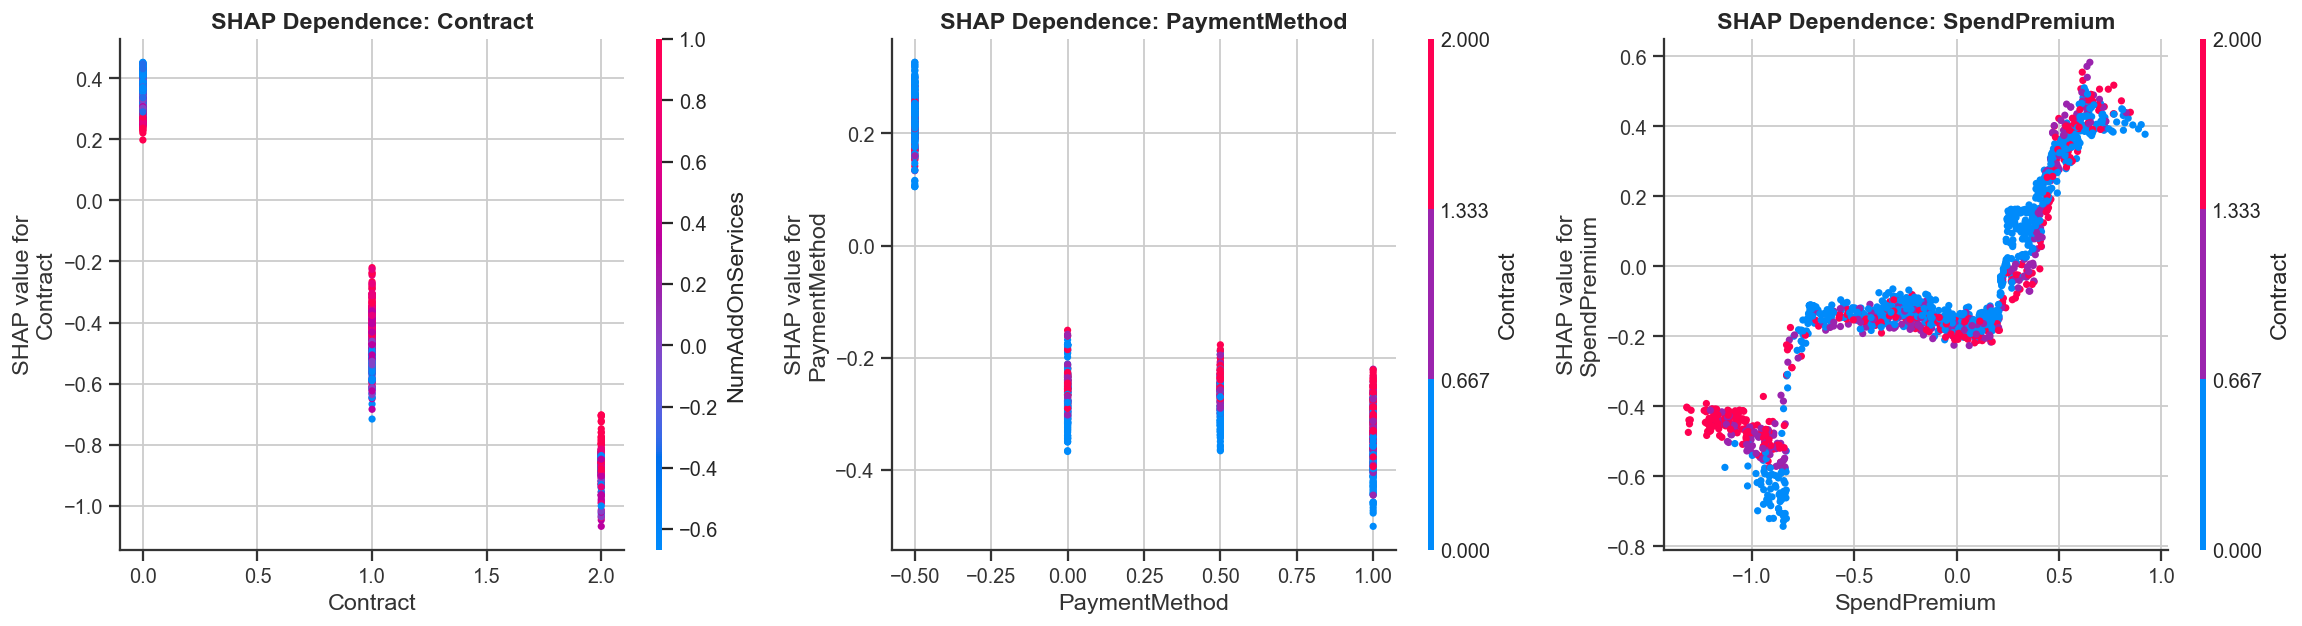

In [ ]:
# 9.2 SHAP Dependence plots
top3_feats = pd.Series(
    np.abs(shap_vals.values).mean(axis=0), index=FEATURE_NAMES
).nlargest(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3_feats):
    shap.dependence_plot(feat, shap_vals.values, X_test_sc,
                         feature_names=FEATURE_NAMES, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {feat}', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_12_shap_dep.png', bbox_inches='tight', dpi=150)
plt.show()

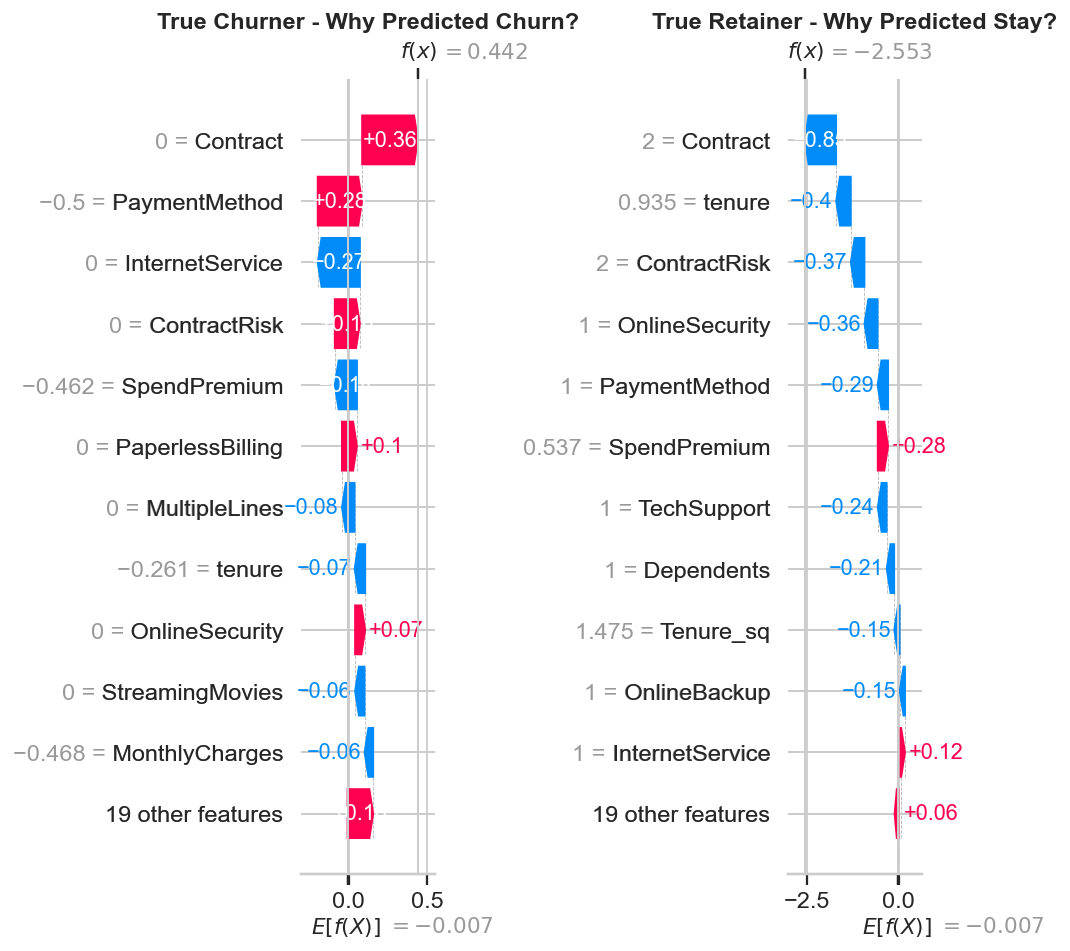

In [32]:
# 9.3 Individual prediction waterfall
# Pick a true churner and a true retainer for explanation
churner_idx  = np.where((y_test.values == 1) & (RESULTS['XGBoost (Tuned)']['pred'] == 1))[0][0]
retainer_idx = np.where((y_test.values == 0) & (RESULTS['XGBoost (Tuned)']['pred'] == 0))[0][0]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, idx, title in zip(
    axes,
    [churner_idx, retainer_idx],
    ['True Churner - Why Predicted Churn?', 'True Retainer - Why Predicted Stay?']
):
    plt.sca(ax)
    shap.plots.waterfall(shap_vals[idx], max_display=12, show=False)
    plt.title(title, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_13_shap_waterfall.png', bbox_inches='tight', dpi=150)
plt.show()

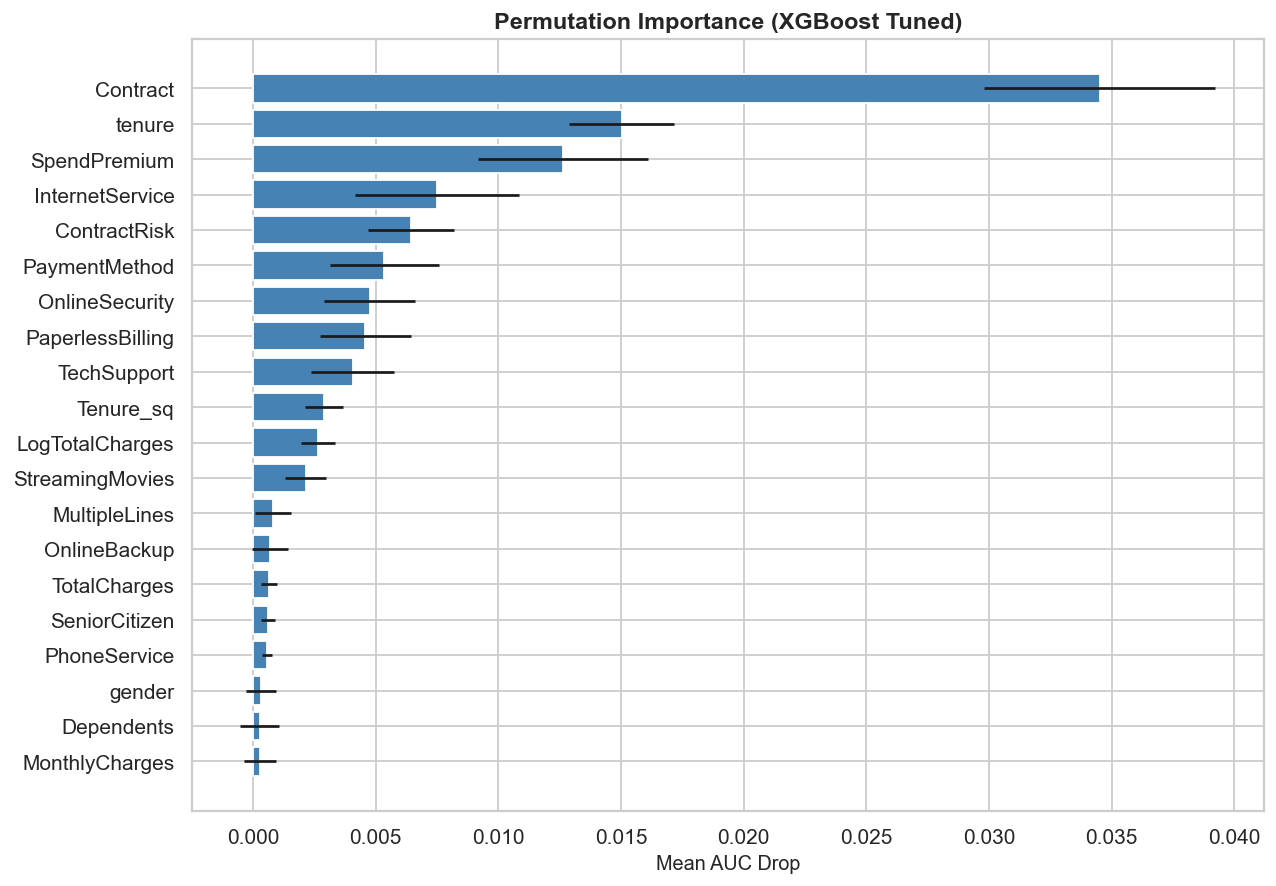

In [33]:
# 9.4 Permutation importance (model-agnostic)
perm = permutation_importance(
    xgb_best, X_test_sc, y_test,
    n_repeats=15, scoring='roc_auc', random_state=SEED, n_jobs=-1
)
perm_df = pd.DataFrame({
    'Feature':     FEATURE_NAMES,
    'Importance':  perm.importances_mean,
    'Std':         perm.importances_std,
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(perm_df['Feature'], perm_df['Importance'],
         xerr=perm_df['Std'], color='steelblue', edgecolor='white')
plt.gca().invert_yaxis()
plt.xlabel('Mean AUC Drop')
plt.title('Permutation Importance (XGBoost Tuned)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_14_perm_imp.png', bbox_inches='tight', dpi=150)
plt.show()

<a id='10'></a>
## 10. Save Artefacts for Deployment

In [34]:
os.makedirs('models', exist_ok=True)

# Choose the best deployable sklearn-style model by ROC-AUC. The ANN is saved
# separately, but the Streamlit app expects a predict_proba-compatible estimator.
deployable_names = [
    name for name, result in RESULTS.items()
    if hasattr(result['model'], 'predict_proba')
]
DEPLOY_MODEL_NAME = max(deployable_names, key=lambda name: RESULTS[name]['auc'])

# Best deployable model for the app.
joblib.dump(RESULTS[DEPLOY_MODEL_NAME]['model'], 'models/deployed_model.pkl')

# Legacy XGBoost artifact kept because SHAP/app examples may refer to it.
joblib.dump(RESULTS['XGBoost (Tuned)']['model'], 'models/xgb_model.pkl')

# Scaler and feature names.
joblib.dump(scaler, 'models/scaler.pkl')
with open('models/feature_names.json', 'w', encoding='utf-8') as f:
    json.dump(FEATURE_NAMES, f, indent=2)

# Encoding maps and feature engineering constants for deployment.
with open('models/ordinal_maps.json', 'w', encoding='utf-8') as f:
    json.dump(ordinal_map, f, indent=2)

metadata = {
    'deployed_model_name': DEPLOY_MODEL_NAME,
    'best_model_name': best_name,
    'decision_threshold': 0.50,
    'monthly_charge_mean': MONTHLY_CHARGE_MEAN,
    'high_charge_threshold': HIGH_CHARGE_THRESHOLD,
    'cohort_monthly_charge_by_tenure': {
        str(int(k)): float(v) for k, v in COHORT_MONTHLY_CHARGE_BY_TENURE.items()
    },
    'feature_engineering': [
        'AvgMonthlySpend',
        'SpendPremium',
        'NumAddOnServices',
        'HasBundle',
        'HasFamily',
        'ContractRisk',
        'AutoPay',
        'HighChargesNewCustomer',
        'Tenure_sq',
        'LogTotalCharges',
        'LogMonthlyCharges',
    ],
    'notes': [
        'App uses deployed_model.pkl when available.',
        'SpendPremium uses saved tenure-level monthly charge averages.',
        'HighChargesNewCustomer uses the saved training-set high-charge threshold.',
    ],
}
with open('models/preprocessing_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

# ANN model and summary CSV.
ann.save('models/ann_model.keras')
summary.reset_index().to_csv('models/model_comparison.csv', index=False)

print('Artefacts saved:')
for f in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f'  models/{f}  ({size:.1f} KB)')
print(f'\nDeployed sklearn model for Streamlit: {DEPLOY_MODEL_NAME}')

Artefacts saved:
  models/ann_best.weights.h5  (699.2 KB)
  models/ann_model.keras  (710.7 KB)
  models/deployed_model.pkl  (617.2 KB)
  models/feature_names.json  (0.6 KB)
  models/model_comparison.csv  (1.5 KB)
  models/ordinal_maps.json  (0.9 KB)
  models/preprocessing_metadata.json  (2.7 KB)
  models/scaler.pkl  (1.7 KB)
  models/xgb_model.pkl  (617.2 KB)

Deployed sklearn model for Streamlit: XGBoost (Tuned)


<a id='11'></a>
## 11. Business Insights & Conclusions

In [35]:
# Cost-benefit analysis at optimal threshold
# Assumptions (adjust to real business numbers)
MONTHLY_REVENUE     = df['MonthlyCharges'].mean()   # avg revenue per customer
RETENTION_COST      = 50.0                          # cost of a retention campaign (discount, call, etc.)
LIFETIME_MONTHS     = 24                            # avg months a retained customer stays

best_probs = RESULTS[best_name]['prob']
best_preds = RESULTS[best_name]['pred']

# TP: correctly flag churner -> save lifetime value, spend retention cost
# FP: flag non-churner -> waste retention cost
# FN: miss churner -> lose lifetime value
# TN: correctly ignore -> no cost

tp = ((best_preds==1) & (y_test==1)).sum()
fp = ((best_preds==1) & (y_test==0)).sum()
fn = ((best_preds==0) & (y_test==1)).sum()
tn = ((best_preds==0) & (y_test==0)).sum()

saved_value  = tp  * (MONTHLY_REVENUE * LIFETIME_MONTHS - RETENTION_COST)
wasted_cost  = fp  * RETENTION_COST
missed_value = fn  * (MONTHLY_REVENUE * LIFETIME_MONTHS)
net_benefit  = saved_value - wasted_cost - missed_value

print('='*60)
print('BUSINESS IMPACT ANALYSIS')
print('='*60)
print(f'Test set size:         {len(y_test):,} customers')
print(f'Avg Monthly Revenue:   ${MONTHLY_REVENUE:.2f}')
print(f'Retention Campaign Cost:${RETENTION_COST:.2f} per customer')
print()
print(f'True Positives  (TP):  {tp:,}  -> saved ${saved_value:,.0f}')
print(f'False Positives (FP):  {fp:,}  -> wasted ${wasted_cost:,.0f}')
print(f'False Negatives (FN):  {fn:,}  -> missed ${missed_value:,.0f}')
print(f'True Negatives  (TN):  {tn:,}')
print()
print(f'Estimated Net Benefit: ${net_benefit:,.0f} on {len(y_test):,} test customers')
roi = (net_benefit / (tp+fp) / RETENTION_COST) if (tp+fp) > 0 else 0
print(f'Campaign ROI:          {roi*100:.1f}%')

BUSINESS IMPACT ANALYSIS
Test set size:         1,409 customers
Avg Monthly Revenue:   $64.76
Retention Campaign Cost:$50.00 per customer

True Positives  (TP):  275  -> saved $413,677
False Positives (FP):  219  -> wasted $10,950
False Negatives (FN):  99  -> missed $153,874
True Negatives  (TN):  816

Estimated Net Benefit: $248,853 on 1,409 test customers
Campaign ROI:          1007.5%


In [36]:
# Final conclusions
best_r = RESULTS[best_name]

print('='*70)
print('PROJECT SUMMARY & CONCLUSIONS')
print('='*70)
print(f"""
DATASET:
  7,043 Telco customers, 20 features, {churn_rate:.1f}% churn rate (imbalanced)

DATA QUALITY FIXES APPLIED:
  OK TotalCharges blank strings -> converted to numeric, imputed with tenure x monthly
  OK Duplicate rows detected and removed
  OK customerID dropped (non-informative)

FEATURE ENGINEERING (11 new features):
  AvgMonthlySpend, SpendPremium, NumAddOnServices, HasBundle, HasFamily,
  ContractRisk, AutoPay, HighChargesNewCustomer, Tenure_sq,
  LogTotalCharges, LogMonthlyCharges

CLASS IMBALANCE HANDLING:
  SMOTE applied on training fold only (test remains original distribution)
  Scale: {churn_rate:.1f}% -> 50% after oversampling

BEST MODEL: {best_name}
  AUC    = {best_r['auc']:.4f}
  F1     = {best_r['f1']:.4f}
  Recall = {best_r['recall']:.4f}  <- critical for churn (minimise FN)
  Brier  = {best_r['brier']:.4f}  <- well-calibrated probabilities

TOP CHURN DRIVERS (SHAP):
  1. Contract type - month-to-month customers churn 3x more
  2. Tenure - first 12 months are the highest-risk window
  3. MonthlyCharges / SpendPremium - high-cost customers more likely to leave
  4. OnlineSecurity / TechSupport - absence significantly raises churn
  5. InternetService - Fiber optic has highest churn rate (42%)

BUSINESS RECOMMENDATIONS:
  - Target month-to-month customers with contract upgrade offers in month 3-6
  - Bundle OnlineSecurity + TechSupport at a discount for at-risk customers
  - Review Fiber optic pricing - high cost-to-churn correlation
  - Switch electronic check customers to auto-pay (reduces friction)
  - Use model scores to prioritise retention call centre resources
""")

PROJECT SUMMARY & CONCLUSIONS

DATASET:
  7,043 Telco customers, 20 features, 26.5% churn rate (imbalanced)

DATA QUALITY FIXES APPLIED:
  OK TotalCharges blank strings -> converted to numeric, imputed with tenure x monthly
  OK Duplicate rows detected and removed
  OK customerID dropped (non-informative)

FEATURE ENGINEERING (11 new features):
  AvgMonthlySpend, SpendPremium, NumAddOnServices, HasBundle, HasFamily,
  ContractRisk, AutoPay, HighChargesNewCustomer, Tenure_sq,
  LogTotalCharges, LogMonthlyCharges

CLASS IMBALANCE HANDLING:
  SMOTE applied on training fold only (test remains original distribution)
  Scale: 26.5% -> 50% after oversampling

BEST MODEL: XGBoost (Tuned)
  AUC    = 0.8453
  F1     = 0.6336
  Recall = 0.7353  <- critical for churn (minimise FN)
  Brier  = 0.1474  <- well-calibrated probabilities

TOP CHURN DRIVERS (SHAP):
  1. Contract type - month-to-month customers churn 3x more
  2. Tenure - first 12 months are the highest-risk window
  3. MonthlyCharges / S